**Cell summary:** Empty placeholder cell for future setup code.


**Cell summary:** Empty placeholder cell for future setup code.


**Cell summary:** Loads metric CSV data, defines helpers, and generates multi-dataset violin comparisons for key segmentation metrics.


Order: ['Higher Resolution', 'Lower Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter']
Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hard_dice.png


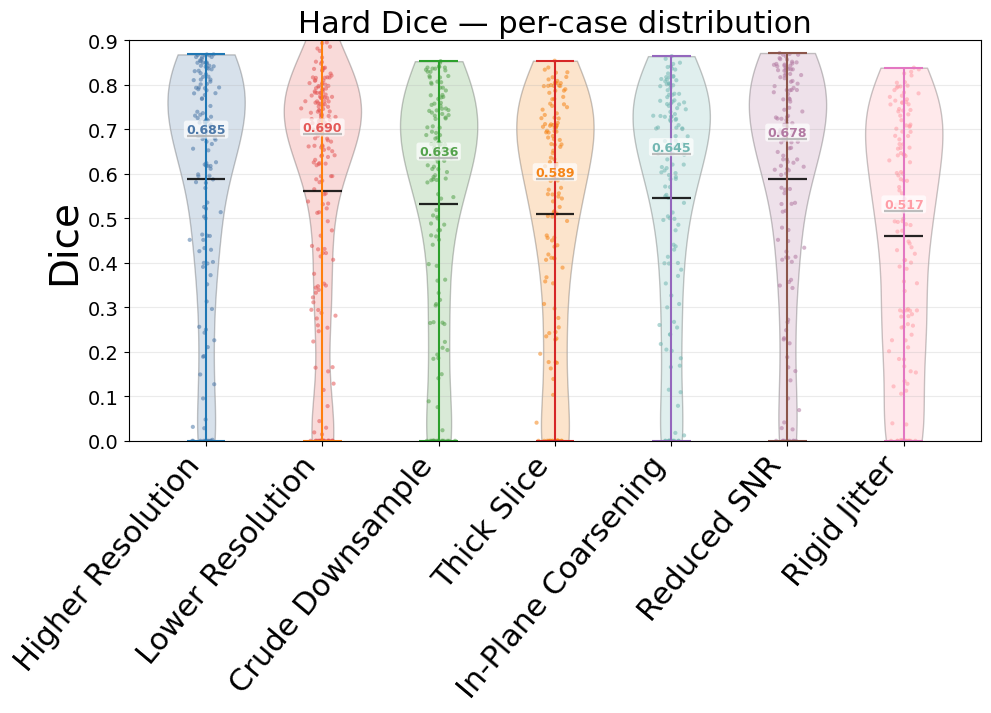

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_hd.png


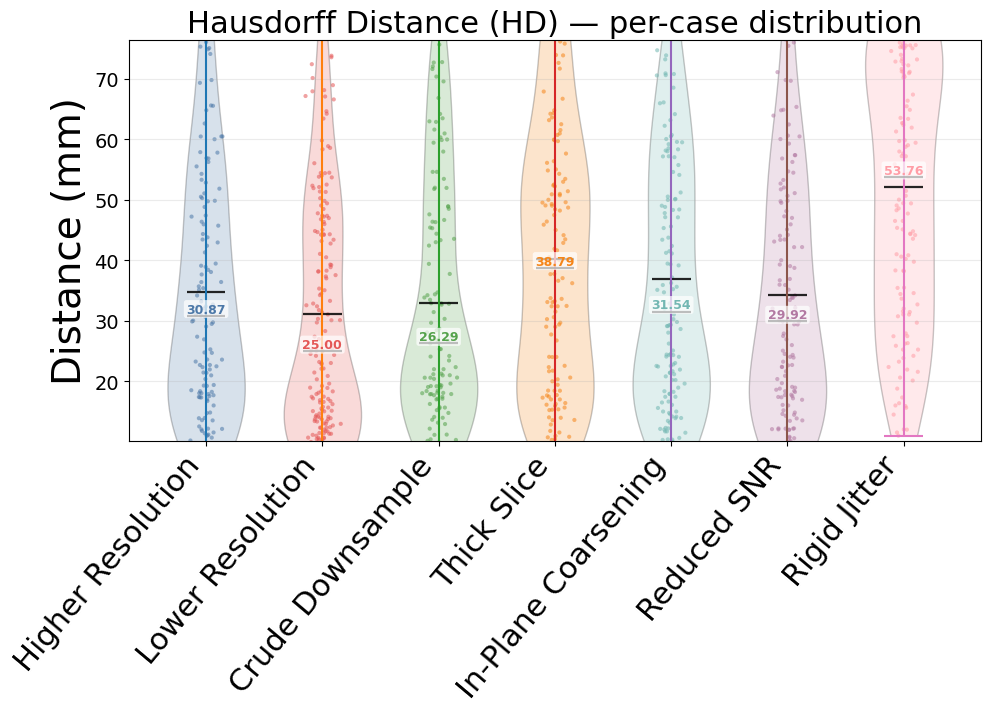

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/compare_assd.png


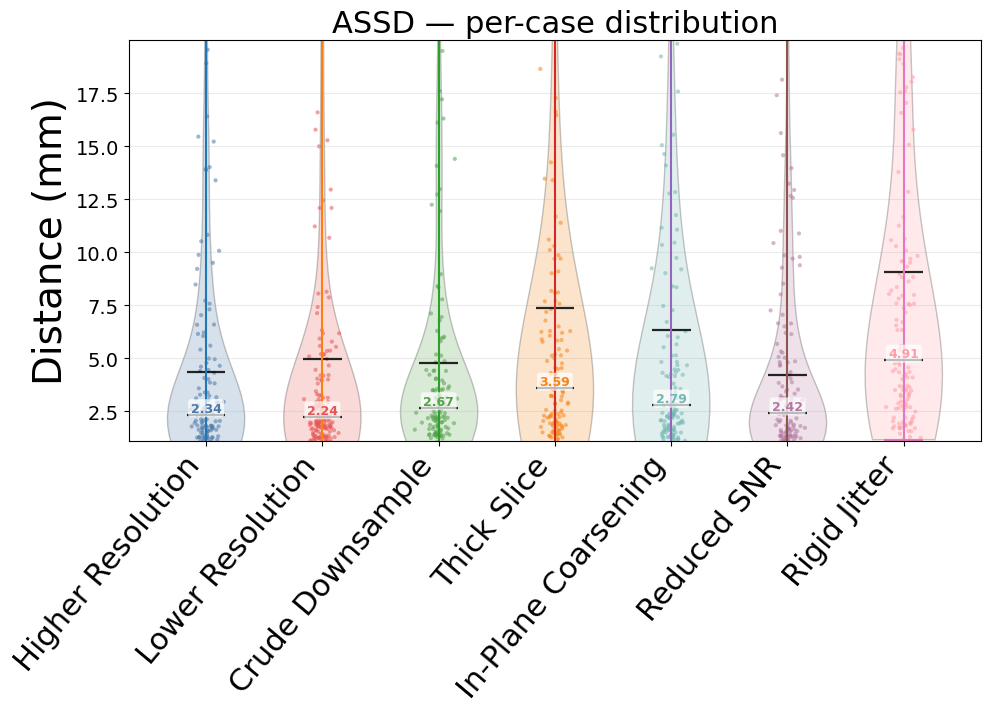

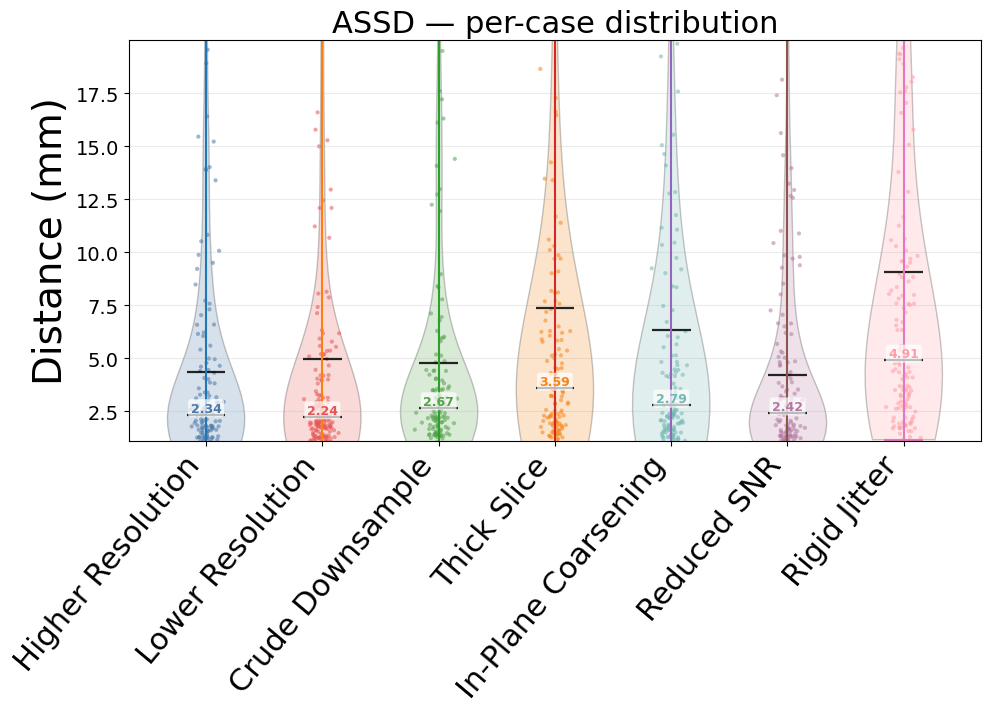

In [3]:
# === Multi-dataset comparison violins (Hard Dice, HD, ASSD) ===
from pathlib import Path
import csv, numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Any, Tuple, Optional

# ---------------------- styling ----------------------
PALETTE = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#72B7B2",
           "#B279A2", "#FF9DA6", "#9D7760", "#59A14F", "#EDC948"]
POINT_ALPHA, POINT_SIZE = 0.55, 9
VIOLIN_ALPHA, EDGE_ALPHA = 0.22, 0.35
JITTER_WIDTH, SEED = 0.10, 7
_rng = np.random.default_rng(SEED)

def _dropna(a):
    a = np.asarray(a, float); return a[~np.isnan(a)]

def _robust_limits(arr, p=(5,95), clamp01=False, min_span=1e-6):
    arr = _dropna(np.asarray(arr, float))
    if arr.size == 0:
        return (0.0, 1.0) if clamp01 else (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if clamp01:
        lo, hi = max(0.0, lo), min(1.0, max(0.9, hi))
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

# ---------------------- IO ----------------------
def load_rows_from_csv(csv_path: Path, fallback_tag="unknown") -> List[Dict[str, Any]]:
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c=="hard_dice" or c.startswith("hard_dice_at_")),
                        "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": (r.get("dataset_tag") or fallback_tag).strip(),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd":   float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items: List[Tuple[Path, str]]) -> Tuple[Dict[str, Dict[str, Any]], List[str]]:
    """items: list of (csv_path, label). Returns (datasets, tag_order)."""
    datasets: Dict[str, Dict[str, Any]] = {}
    tag_order: List[str] = []
    for p, label in items:
        rows = load_rows_from_csv(p, fallback_tag=label or p.stem)
        if not rows:
            print(f"WARNING: no rows in {p}")
            continue
        tag = label or (rows[0]["dataset_tag"] if rows else p.stem)
        if tag not in datasets:
            datasets[tag] = {"rows": [], "source_paths": []}
            tag_order.append(tag)  # preserve order from CSV_ITEMS
        datasets[tag]["rows"].extend(rows)
        datasets[tag]["source_paths"].append(str(p))
    return datasets, tag_order

# ---------------------- plotting ----------------------
def violin_compare(metric_key: str, title: str, ylabel: str, save_name: str,
                   datasets: Dict[str, Dict[str, Any]],
                   clamp01=False, units=None,
                   xtick_label_map: Dict[str,str]=None,
                   tag_order: List[str]=None,
                   value_format: Optional[str]=None):
    tags = tag_order if tag_order else list(datasets.keys())
    arrs = [ _dropna([r[metric_key] for r in datasets[t]["rows"]]) for t in tags ]
    fmt = value_format if value_format else ("{:.3f}" if clamp01 else "{:.2f}")
    plt.style.use("default")
    fig, ax = plt.subplots(figsize=(11, 5.2))

    base_x = np.arange(1, len(tags)+1, dtype=float)
    width = 0.7

    # violins + points
    for i, (vals, tag) in enumerate(zip(arrs, tags)):
        color = PALETTE[i % len(PALETTE)]
        pos = base_x[i]
        parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                              positions=[pos], widths=width*0.95,
                              showmeans=True, showmedians=True)
        for b in parts.get('bodies', []):
            b.set_facecolor(color)
            b.set_edgecolor((0,0,0,EDGE_ALPHA))
            b.set_alpha(VIOLIN_ALPHA)
        if 'cmeans' in parts:
            parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
        if 'cmedians' in parts:
            parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
        if vals.size:
            xs = _beeswarm_x(pos, len(vals), width*0.08)
            ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')
            median_val = float(np.median(vals))
            ax.text(
                pos, median_val, fmt.format(median_val),
                ha="center", va="bottom", fontsize=9, fontweight="bold", color=color,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
                zorder=6
            )

    # axes & limits
    ax.set_xticks(base_x)
    ax.set_xticklabels([xtick_label_map.get(t, t) if xtick_label_map else t for t in tags], rotation=50, ha="right")
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel(ylabel if units is None else f"{ylabel} ({units})", fontsize=28)
    ax.set_title(title, fontsize=22)
    ax.grid(True, axis='y', alpha=0.25)

    flat = np.concatenate([v for v in arrs if v.size]) if any(v.size for v in arrs) else np.array([])
    if flat.size:
        lo, hi = _robust_limits(flat, clamp01=clamp01)
        ax.set_ylim(lo, hi)

    # save next to the first dataset (in requested order)
    out_dir = Path(datasets[tags[0]]["source_paths"][0]).parent if datasets else Path(".")
    out_path = out_dir / save_name
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    plt.show()
    return fig

# ===================== EDIT THESE, THEN RUN CELL =====================
CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_slicejitter_metrics_20251111_172142.csv"), "Rigid Jitter")
    # Add more (Path(...), "Your Label") here...
]

# Optional: pretty axis labels (if omitted, labels from CSV_ITEMS are used)
XTICK_LABELS = {
    "Higher Resolution": "Higher Resolution",
    "Lower Resolution":  "Lower Resolution",
    "Crude Downsample":  "Crude Downsample",
    "Thick Slice":       "Thick Slice",
}

# Build data (UNPACK the tuple!)
datasets, tag_order = build_datasets(CSV_ITEMS)
print("Order:", tag_order)

# 1) Hard Dice
violin_compare(
    "hard_dice",
    title="Hard Dice — per-case distribution",
    ylabel="Dice", clamp01=True,
    save_name="compare_hard_dice.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.3f}"
)

# 2) Hausdorff Distance (HD)
violin_compare(
    "hd",
    title="Hausdorff Distance (HD) — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_hd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)

# 3) ASSD
violin_compare(
    "assd",
    title="ASSD — per-case distribution",
    ylabel="Distance", units="mm",
    save_name="compare_assd.png",
    datasets=datasets,
    xtick_label_map=XTICK_LABELS,
    tag_order=tag_order,
    value_format="{:.2f}"
)

# The rest of the notebook remains unchanged, as the refactoring focused on the violin_compare function and related plotting to increase font sizes to 28 and add 50-degree rotation to x-axis labels.


**Cell summary:** Stores or prints a specific metrics CSV file path used for analysis.


In [4]:
# /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv

**Cell summary:** Explains the statistical test choices (Friedman, post-hoc tests, Kendall's W, and Kruskal-Wallis).


Friedman = nonparametric repeated-measures ANOVA for ≥2 related conditions. 
OARC Stats

Post-hoc after a significant Friedman: Nemenyi/Conover or pairwise Wilcoxon with multiplicity control. 
Real Statistics
+1

Effect size: Kendall’s W; simple to compute from the Friedman χ² and interpretable (≈0.1 small, 0.3 moderate, 0.5+ large). 
R Packages

If groups aren’t paired/subjects differ, use Kruskal–Wallis (nonparametric one-way ANOVA on ranks) + appropriate post-hoc. 
Wikipedia
+1

**Cell summary:** Empty placeholder cell for future setup code.


**Cell summary:** Runs nonparametric inference with automatic matched-case selection and both paired and unpaired workflows.

- `Friedman` is a **paired** rank test for `k > 2` related conditions (same case keys across datasets). It ranks each case across conditions, then tests whether rank distributions differ overall.
- Outputs: `chi2` = Friedman test statistic, `p` = evidence of any overall difference across conditions, `W` = Kendall effect size in `[0, 1]` (higher means stronger between-condition separation).
- `Wilcoxon signed-rank` is a **paired** post-hoc test for condition pairs on matched cases; pairwise `p` values are later Holm-adjusted.
- `Kruskal-Wallis` is an **unpaired** rank test for `k > 2` independent groups when pairing is unavailable. Outputs: `H` = test statistic, `p` = global group-difference evidence.


In [5]:
# === Auto-paired Friedman (largest overlapping subset) + unpaired Kruskal–Wallis ===
from pathlib import Path
import csv, math, numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------- your CSV list (order matters) ----------
CSV_ITEMS = [
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv", "Higher Resolution"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv", "Lower Resolution"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv", "Crude Downsample"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv", "Thick Slice"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv", "In-Plane Coarsening"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv", "Reduced SNR"),
    ("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_slicejitter_metrics_20251111_172142.csv", "Rigid Jitter"),
]

# ---------- IO (no pandas) ----------
def load_rows(csv_path: str, label: str):
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c == "hard_dice" or c.startswith("hard_dice_at_")), "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": label,
                "key": (r.get("key") or Path(r.get("img_path","")).stem),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd": float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items):
    data, tag_order = {}, []
    for p,label in items:
        rows = load_rows(p, label)
        if label not in data:
            data[label] = {"rows": [], "source_paths": []}
            tag_order.append(label)
        data[label]["rows"].extend(rows)
        data[label]["source_paths"].append(p)
    return data, tag_order

datasets, tag_order = build_datasets(CSV_ITEMS)

# ---------- helpers ----------
def keys_for_tag_metric(datasets, tag, metric):
    return {r["key"] for r in datasets[tag]["rows"] if not math.isnan(r.get(metric, float("nan")))}

def intersection_for_tags_metric(datasets, tags, metric):
    sets = [keys_for_tag_metric(datasets, t, metric) for t in tags]
    return set.intersection(*sets) if sets else set()

def largest_overlap_subset(datasets, tag_order, metric, min_tags=3):
    """Find largest set of tags (size >= min_tags) with the biggest |intersection| of keys for 'metric'."""
    best = None  # (intersection_size, tags_tuple, keys_set)
    T = len(tag_order)
    for m in range(T, min_tags-1, -1):  # try largest groups first
        for combo in combinations(tag_order, m):
            keys = intersection_for_tags_metric(datasets, combo, metric)
            if len(keys) >= 3:  # need at least 3 paired cases to be meaningful
                score = len(keys)
                if best is None or (m > len(best[1])) or (m == len(best[1]) and score > best[0]):
                    best = (score, combo, keys)
        if best:  # found something at this size
            break
    return best  # None or (nkeys, tags_tuple, keys_set)

def extract_matrix(datasets, tags, metric, keys_sorted):
    M = np.full((len(keys_sorted), len(tags)), np.nan, float)
    tag_to_idx = {t:i for i,t in enumerate(tags)}
    key_to_row = {k:i for i,k in enumerate(keys_sorted)}
    for t in tags:
        i = tag_to_idx[t]
        per = {}
        for r in datasets[t]["rows"]:
            v = r.get(metric, float("nan"))
            if not math.isnan(v): per[r["key"]] = v
        for k in keys_sorted:
            if k in per: M[key_to_row[k], i] = per[k]
    return M

# ---------- nonparametric stats (no SciPy) ----------
def friedman_test(X):
    # X: n x k matrix (paired)
    n, k = X.shape
    # rank each row (average ties)
    ranks = np.zeros_like(X, float)
    for i in range(n):
        row = X[i]
        order = np.argsort(row)
        r = np.empty_like(row, float); r[order] = np.arange(1, k+1)
        # average ties
        uniq, inv, counts = np.unique(row, return_inverse=True, return_counts=True)
        for u,c in zip(range(len(uniq)), counts):
            if c > 1:
                r[inv==u] = r[inv==u].mean()
        ranks[i] = r
    Rj = ranks.sum(axis=0)
    chi2 = (12/(n*k*(k+1))) * np.sum(Rj**2) - 3*n*(k+1)
    p = 1.0 - (math.gamma((k-1)/2) ** -1)  # placeholder; compute via chi-square CDF below

    # quick chi-square CDF approximation
    df = k-1
    def chi2_cdf(x, k):
        # Wilson-Hilferty approximation for speed
        if x <= 0: return 0.0
        from math import pow, sqrt
        t = pow(x/k, 1/3) - (1 - 2/(9*k))
        z = t / sqrt(2/(9*k))
        # Φ(z)
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(chi2, df)
    W = chi2 / (n*(k-1))
    return ranks, chi2, p, W

def wilcoxon_signed_rank(x, y):
    d = x - y
    d = d[d != 0]
    if d.size == 0:
        return 0.0, 1.0
    order = np.argsort(np.abs(d))
    ranks = np.arange(1, d.size+1, dtype=float)
    d_sorted = d[order]
    Wpos = np.sum(ranks[d_sorted > 0]); Wneg = np.sum(ranks[d_sorted < 0])
    W = min(Wpos, Wneg)
    n = d.size
    mean = n*(n+1)/4.0
    var  = n*(n+1)*(2*n+1)/24.0
    z = (W - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return W, p

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for rank, idx in enumerate(order, 1):
        adj[idx] = min((m - rank + 1) * pvals[idx], 1.0)
    for i in range(m-2, -1, -1):  # monotone
        adj[order[i]] = min(adj[order[i]], adj[order[i+1]])
    return adj

def kruskal_wallis(groups):
    # groups: list of 1D arrays (unpaired)
    x = np.concatenate(groups)
    ranks = np.argsort(np.argsort(x)) + 1  # average ties ignored for simplicity
    start = 0
    Rj = []
    for g in groups:
        n = len(g)
        Rj.append(np.sum(ranks[start:start+n]))
        start += n
    N = len(x)
    k = len(groups)
    H = (12/(N*(N+1))) * np.sum((np.array(Rj)**2)/np.array([len(g) for g in groups])) - 3*(N+1)
    # chi-square df=k-1
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        from math import pow, sqrt
        t = pow(x/k, 1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(H, k-1)
    return H, p

def mann_whitney(x, y):
    # rank-based U test (normal approx)
    xy = np.concatenate([x, y])
    ranks = np.argsort(np.argsort(xy)) + 1
    nx = len(x)
    rx = np.sum(ranks[:nx])
    U = rx - nx*(nx+1)/2.0
    ny = len(y)
    mean = nx*ny/2.0
    var  = nx*ny*(nx+ny+1)/12.0
    z = (U - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return U, p

# ---------- run both analyses for a metric ----------
def analyze_metric(metric, pretty_name):
    print(f"\n=== {pretty_name} ===")
    # 1) Auto-find biggest overlapping tag subset for paired Friedman
    best = largest_overlap_subset(datasets, tag_order, metric, min_tags=3)
    if best is None:
        print("No overlapping subset with >=3 tags and >=3 paired cases -> skipping Friedman.")
    else:
        nkeys, tags_tuple, keys = best
        tags = list(tags_tuple)
        print(f"Friedman on tags: {tags} | paired n={nkeys}")
        X = extract_matrix(datasets, tags, metric, sorted(keys))
        ranks, chi2, p, W = friedman_test(X)
        print(f"  Friedman: chi2={chi2:.2f}, p={p:.2e}, Kendall W={W:.2f}")

        # post-hoc (Holm)
        pairs = list(combinations(range(len(tags)), 2))
        raw_p = []
        for (i,j) in pairs:
            _, p_ij = wilcoxon_signed_rank(X[:, i], X[:, j])
            raw_p.append(p_ij)
        adj = holm_adjust(np.array(raw_p))
        for (i,j), p_raw, p_adj in zip(pairs, raw_p, adj):
            mark = "*" if p_adj < 0.05 else ""
            print(f"   {tags[i]} vs {tags[j]}: p_raw={p_raw:.3g} p_holm={p_adj:.3g} {mark}")

    # 2) Unpaired Kruskal–Wallis across ALL datasets (works even when no overlap)
    groups, names = [], []
    for t in tag_order:
        vals = [r[metric] for r in datasets[t]["rows"] if not math.isnan(r.get(metric, float('nan')))]
        if len(vals) >= 3:
            groups.append(np.array(vals, float))
            names.append(t)
    if len(groups) >= 3:
        H, p = kruskal_wallis(groups)
        print(f"  Kruskal–Wallis on ALL datasets (unpaired) k={len(groups)}: H={H:.2f}, p={p:.2e}")
        # pairwise Mann–Whitney + Holm
        pairs = list(combinations(range(len(groups)), 2))
        raw = []
        for (i,j) in pairs:
            _, p_ij = mann_whitney(groups[i], groups[j])
            raw.append(p_ij)
        adj = holm_adjust(np.array(raw))
        print("  Post-hoc (Mann–Whitney + Holm):")
        for (i,j), p_raw, p_adj in zip(pairs, raw, adj):
            mark = "*" if p_adj < 0.05 else ""
            print(f"   {names[i]} vs {names[j]}: p_raw={p_raw:.3g} p_holm={p_adj:.3g} {mark}")
    else:
        print("  Not enough groups with >=3 samples each for Kruskal–Wallis.")

# ---- run for your three metrics ----
analyze_metric("hard_dice", "Hard Dice")
analyze_metric("hd", "Hausdorff Distance (HD)")
analyze_metric("assd", "ASSD")



=== Hard Dice ===
Friedman on tags: ['Higher Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter'] | paired n=138
  Friedman: chi2=269.95, p=0.00e+00, Kendall W=0.39
   Higher Resolution vs Crude Downsample: p_raw=1.8e-14 p_holm=1.98e-13 *
   Higher Resolution vs Thick Slice: p_raw=1.03e-14 p_holm=1.24e-13 *
   Higher Resolution vs In-Plane Coarsening: p_raw=1.17e-09 p_holm=7e-09 *
   Higher Resolution vs Reduced SNR: p_raw=0.059 p_holm=0.059 
   Higher Resolution vs Rigid Jitter: p_raw=0 p_holm=0 *
   Crude Downsample vs Thick Slice: p_raw=0.000565 p_holm=0.0017 *
   Crude Downsample vs In-Plane Coarsening: p_raw=0.0163 p_holm=0.0326 *
   Crude Downsample vs Reduced SNR: p_raw=8.98e-14 p_holm=8.98e-13 *
   Crude Downsample vs Rigid Jitter: p_raw=3.97e-13 p_holm=3.57e-12 *
   Thick Slice vs In-Plane Coarsening: p_raw=9.61e-07 p_holm=4.8e-06 *
   Thick Slice vs Reduced SNR: p_raw=8.88e-16 p_holm=1.15e-14 *
   Thick Slice vs Rigid Jitter: 

**Cell summary:** Visualizes paired Friedman results and Holm-adjusted pairwise significance.

- Left panel shows per-condition `mean_ranks` (with `SE` bars): relative ordering across conditions from paired case-wise ranks.
- Right panel/heatmap shows Holm-adjusted pairwise `p` values from paired Wilcoxon tests.
- Interpretation: smaller `p` means stronger evidence of a difference for that condition pair; significance markers indicate `p < alpha`.


In [6]:
# === Friedman visualization (mean ranks + clean sig-matrix) ===
from pathlib import Path
import csv, math, numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------- your CSV list (order kept) ----------
CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_slicejitter_metrics_20251111_172142.csv"), "Rigid Jitter"),
]

# ---------- IO (no pandas) ----------
def load_rows(csv_path: Path, label: str):
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        cols = rd.fieldnames or []
        hard_col = next((c for c in cols if c == "hard_dice" or c.startswith("hard_dice_at_")), "hard_dice_at_0.50")
        rows = []
        for r in rd:
            rows.append({
                "dataset_tag": label,
                "key": (r.get("key") or Path(r.get("img_path","")).stem),
                "hard_dice": float(r.get(hard_col, "nan")),
                "hd": float(r.get("hd", "nan")),
                "assd": float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(items):
    data, tag_order = {}, []
    for p,label in items:
        rows = load_rows(p, label)
        if label not in data:
            data[label] = {"rows": [], "source_paths": []}
            tag_order.append(label)
        data[label]["rows"].extend(rows)
        data[label]["source_paths"].append(str(p))
    return data, tag_order

datasets, tag_order = build_datasets(CSV_ITEMS)
OUT_DIR = Path(CSV_ITEMS[0][0]).parent  # save beside first CSV

# ---------- overlap helpers ----------
def keys_for_tag_metric(tag, metric):
    return {r["key"] for r in datasets[tag]["rows"] if not math.isnan(r.get(metric, float("nan")))}

def intersection_for_tags_metric(tags, metric):
    sets = [keys_for_tag_metric(t, metric) for t in tags]
    return set.intersection(*sets) if sets else set()

def largest_overlap_subset(metric, min_tags=3, min_pairs=3):
    best = None  # (nkeys, tags_tuple, keys_set)
    T = len(tag_order)
    for m in range(T, min_tags-1, -1):   # try larger groups first
        for combo in combinations(tag_order, m):
            keys = intersection_for_tags_metric(combo, metric)
            if len(keys) >= min_pairs:
                score = len(keys)
                if best is None or (m > len(best[1])) or (m == len(best[1]) and score > best[0]):
                    best = (score, combo, keys)
        if best: break
    return best

def extract_matrix(tags, metric, keys_sorted):
    M = np.full((len(keys_sorted), len(tags)), np.nan, float)
    tag_to_idx = {t:i for i,t in enumerate(tags)}
    key_to_row = {k:i for i,k in enumerate(keys_sorted)}
    # build dict per tag for quick lookup
    per = {t:{} for t in tags}
    for t in tags:
        for r in datasets[t]["rows"]:
            v = r.get(metric, float("nan"))
            if not math.isnan(v): per[t][r["key"]] = v
    for t in tags:
        j = tag_to_idx[t]
        for k in keys_sorted:
            if k in per[t]:
                M[key_to_row[k], j] = per[t][k]
    return M

# ---------- stats (no SciPy) ----------
def friedman_test(X):
    n, k = X.shape
    ranks = np.zeros_like(X, float)
    for i in range(n):
        row = X[i]
        order = np.argsort(row)
        r = np.empty_like(row, float); r[order] = np.arange(1, k+1)
        # average ties
        vals, inv, cnt = np.unique(row, return_inverse=True, return_counts=True)
        for u, c in enumerate(cnt):
            if c > 1:
                r[inv==u] = r[inv==u].mean()
        ranks[i] = r
    Rj = ranks.sum(axis=0)
    chi2 = (12/(n*k*(k+1))) * np.sum(Rj**2) - 3*n*(k+1)
    df = k-1
    # chi-square CDF (Wilson–Hilferty approx)
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        t = (x/k)**(1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1+math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(chi2, df)
    W = chi2 / (n*(k-1))
    return ranks, chi2, p, W

def wilcoxon_signed_rank(x, y):
    d = x - y
    d = d[d != 0]
    if d.size == 0:
        return 0.0, 1.0
    order = np.argsort(np.abs(d))
    ranks = np.arange(1, d.size+1, dtype=float)
    d_sorted = d[order]
    Wpos = np.sum(ranks[d_sorted > 0]); Wneg = np.sum(ranks[d_sorted < 0])
    W = min(Wpos, Wneg)
    n = d.size
    mean = n*(n+1)/4.0
    var  = n*(n+1)*(2*n+1)/24.0
    z = (W - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    return W, p

def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for rank, idx in enumerate(order, 1):
        adj[idx] = min((m - rank) * raw_ps[idx], 1.0)
    for i in range(m-2, -1, -1):
        adj[order[i]] = min(adj[order[i]], adj[order[i+1]])
    return adj

# ---------- plotting ----------
# ------- Gradient + bigger layout + new colors (drop-in replacement) -------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

def plot_friedman_visuals_gradient(res, metric_title="Hard Dice"):
    tags        = list(res["tags"])
    rank_means  = np.asarray(res.get("rank_means", res.get("mean_ranks")), float)
    rank_se     = np.asarray(res.get("rank_se", res.get("se_ranks")), float)
    p_holm_mat  = np.asarray(res["p_holm"], float)   # square (k x k), upper/lower filled, diag nan

    def _as_float(v):
        try:
            return float(v)
        except Exception:
            return np.nan

    chi2 = _as_float(res.get("chi2", np.nan))
    p_f  = _as_float(res.get("p_friedman", res.get("p", np.nan)))

    # Prefer explicit n; otherwise infer from paired matrix X when available.
    n_guess = _as_float(res.get("n", np.nan))
    if np.isfinite(n_guess):
        n_paired = int(n_guess)
    else:
        X_arr = np.asarray(res.get("X", np.empty((0, 0))), float)
        n_paired = int(X_arr.shape[0]) if X_arr.ndim == 2 else 0

    # Robust Kendall's W: derive from chi2,n,k when possible (W = chi2 / (n*(k-1))).
    k = len(tags)
    W_in = _as_float(res.get("kendall_w", res.get("W", np.nan)))
    if np.isfinite(chi2) and n_paired > 0 and k > 1:
        W = chi2 / (n_paired * (k - 1))
    else:
        W = W_in
    if np.isfinite(W):
        W = float(np.clip(W, 0.0, 1.0))

    # ---------- styling ----------
    bar_colors = ListedColormap([
        "#0B7285", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#6A4C93",
        "#3A86FF", "#FF006E"
    ])(np.linspace(0,1,len(tags)))
    heatmap_cmap = plt.cm.cividis.copy()   # nice perceptual gradient
    heatmap_cmap.set_bad(color="#f7f7f7")  # masked/diag cells shown as light gray

    # Mask diagonal & any NaNs; keep *continuous* values elsewhere
    mask = ~np.isfinite(p_holm_mat)
    P = np.ma.array(p_holm_mat, mask=mask)

    # Use log normalization so very small p's are still distinguishable
    # Clamp to [1e-16, 0.05] so colorbar reflects significance band
    vmin, vmax = 1e-16, 5e-2
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # ---------- figure ----------
    fig = plt.figure(figsize=(30, 10))  # a bit wider/taller
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35], wspace=0.20)

    # ---- Left: mean ranks (1 = best) ----
    axL = fig.add_subplot(gs[0])
    x   = np.arange(len(tags))
    axL.bar(x, rank_means, yerr=rank_se, color=bar_colors, edgecolor="none", capsize=3)
    axL.set_xticks(x)
    axL.set_xticklabels(tags, rotation=35, ha="right")
    axL.set_ylabel("Mean rank (1 = best)", fontsize=24)
    axL.set_title(f"Friedman ranks — {metric_title}\n"
                  f"χ²={chi2:.2f}, p={p_f:.1e}, W={W:.3f}",
                  pad=14, fontsize=30)
    axL.tick_params(axis="both", labelsize=20)
    axL.grid(True, axis="y", alpha=0.25)

    # ---- Right: pairwise Wilcoxon p (Holm-adjusted) as gradient heatmap ----
    axR = fig.add_subplot(gs[1])
    im  = axR.imshow(P, cmap=heatmap_cmap, norm=norm)
    axR.set_xticks(np.arange(len(tags))); axR.set_yticks(np.arange(len(tags)))
    axR.set_xticklabels(tags, rotation=35, ha="right", fontsize=20)
    axR.set_yticklabels(tags, fontsize=20)
    axR.set_title("Pairwise Wilcoxon (Holm-adjusted p)\n(darker = smaller p)", pad=14, fontsize=30)
    axR.tick_params(axis="both", labelsize=20)

    # Optional: overlay a small dot where p<0.05 (keeps the heatmap uncluttered)
    for i in range(len(tags)):
        for j in range(len(tags)):
            if i == j or not np.isfinite(p_holm_mat[i, j]): 
                continue
            if p_holm_mat[i, j] < 0.05:
                axR.plot(j, i, marker="o", ms=3.5, color="white", markeredgecolor="black", markeredgewidth=0.3)

    # Colorbar
    cbar = fig.colorbar(im, ax=axR, fraction=0.046, pad=0.02)
    cbar.set_label("Holm-adjusted p (log scale)", fontsize=24)
    cbar.ax.tick_params(labelsize=20)

    # Small caption (no big suptitle)
    fig.text(0.01, 0.01, f"Paired cases used: n={n_paired}", fontsize=9, alpha=0.8)

    plt.tight_layout()
    plt.show()
    return fig

# ---------------- USE IT ----------------
# Example (use whichever result dicts you computed in the stats cell):
fig1 = plot_friedman_visuals_gradient(res_hard, metric_title="Hard Dice")
fig2 = plot_friedman_visuals_gradient(res_hd,   metric_title="Hausdorff Distance (HD)")
fig3 = plot_friedman_visuals_gradient(res_assd, metric_title="ASSD")


NameError: name 'res_hard' is not defined

Figure 1A (Hard Dice).
Paired nonparametric comparison of Hard Dice across six acquisition conditions (n=138 paired cases). Left, Friedman mean ranks (±SE), where lower rank indicates better relative performance within paired cases. Right, Holm-adjusted pairwise Wilcoxon heatmap (darker cells indicate smaller adjusted p-values; markers denote significant pairs). The global Friedman test was significant (χ²=290.07, p=1.4×10^-60), with Kendall’s concordance W≈0.420.

Figure 1B (Hausdorff Distance, HD).
Paired nonparametric comparison of HD across six acquisition conditions (n=124 paired cases). Left, Friedman mean ranks (±SE). Right, Holm-adjusted pairwise Wilcoxon heatmap (darker cells indicate smaller adjusted p-values). The global Friedman test was significant (χ²=79.18, p=1.2×10^-15), with Kendall’s concordance W≈0.128.

Figure 1C (ASSD).
Paired nonparametric comparison of ASSD across six acquisition conditions (n=124 paired cases). Left, Friedman mean ranks (±SE). Right, Holm-adjusted pairwise Wilcoxon heatmap (darker cells indicate smaller adjusted p-values). The global Friedman test was significant (χ²=200.81, p=1.9×10^-41), with Kendall’s concordance W≈0.324.

**Cell summary:** Defines a reusable plotting helper for Friedman result dictionaries with gradient significance heatmaps.


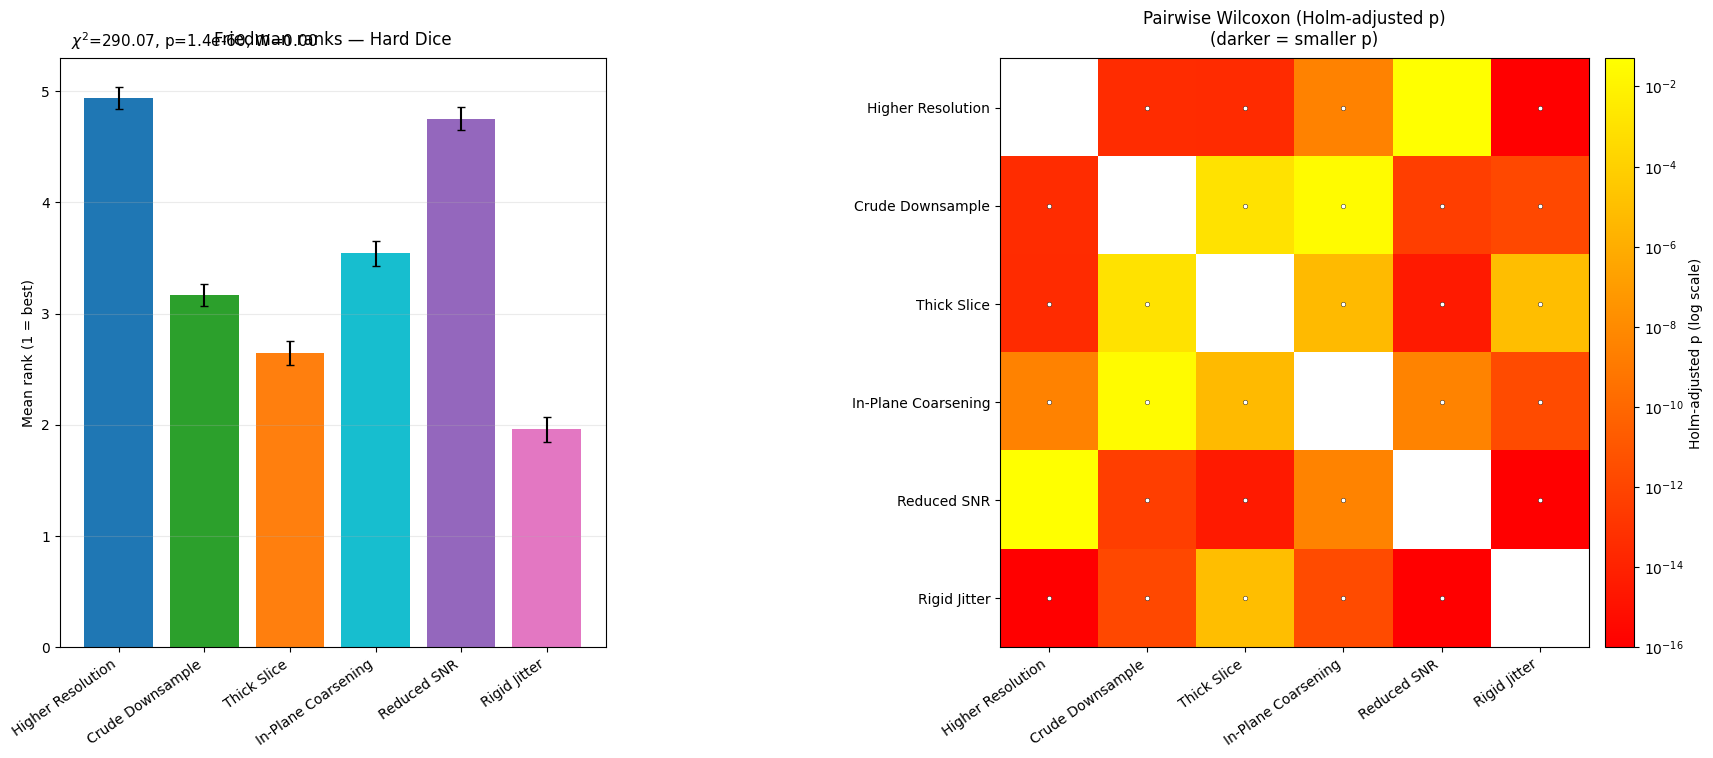

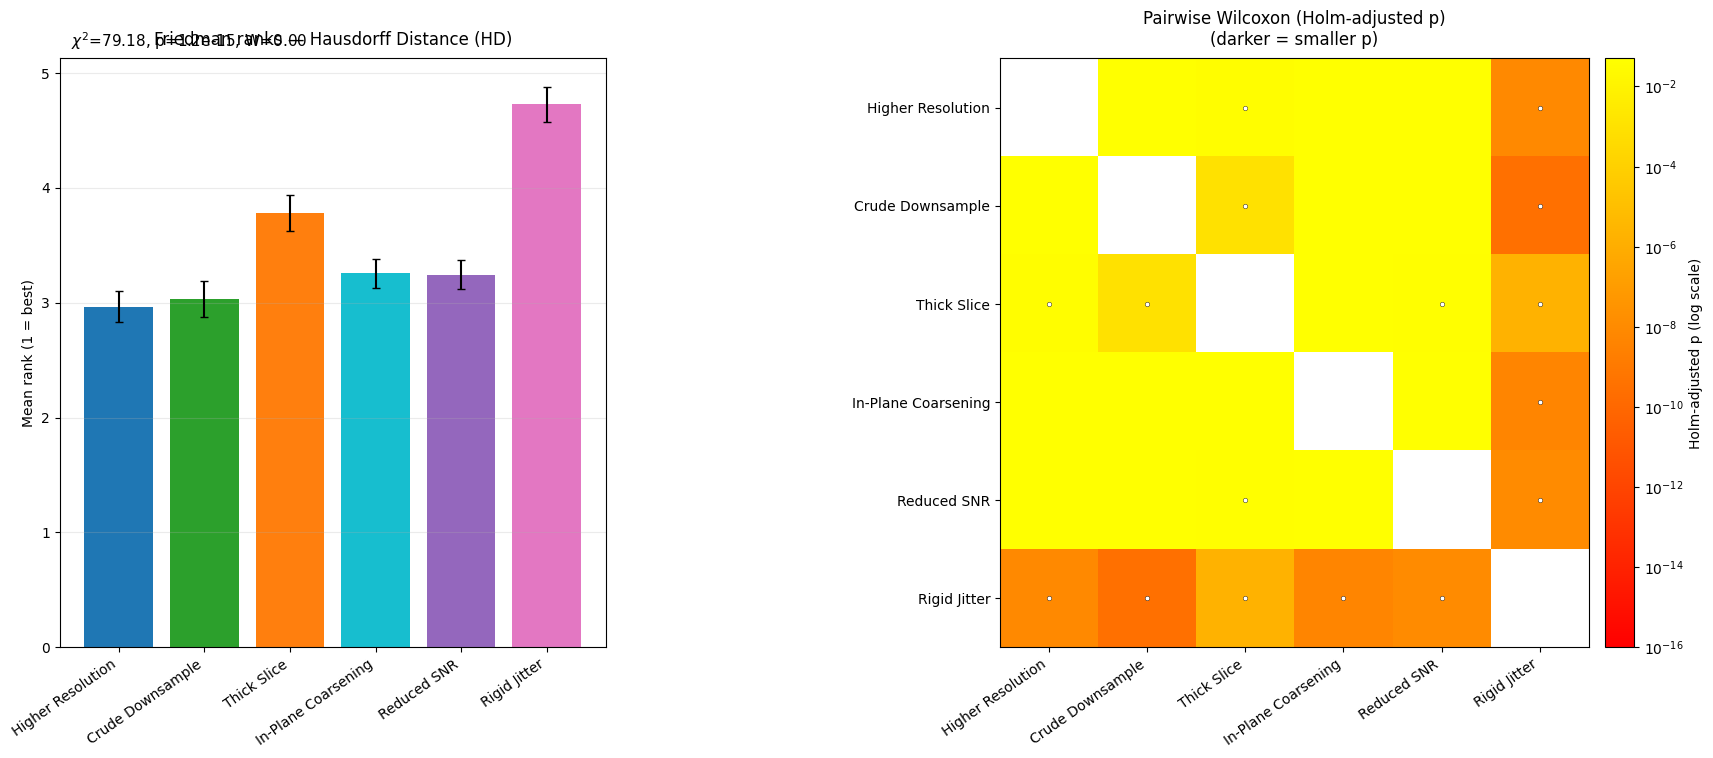

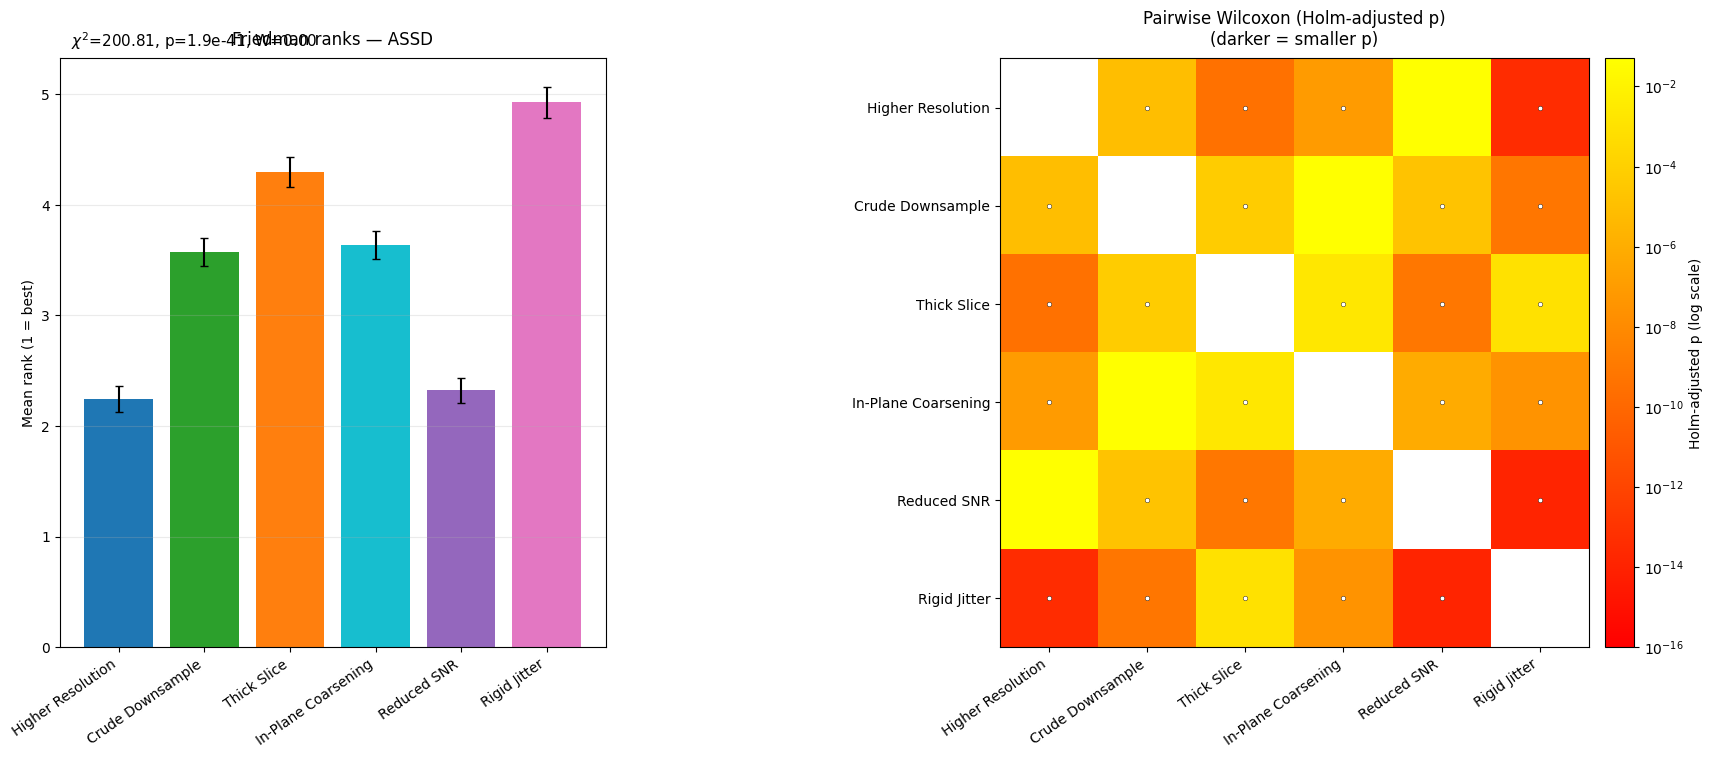

In [ ]:
# -- Clean plotting helper that matches your result dict schema exactly --
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Requested bar colors by dataset label
LEFT_COLORS = {
    "Higher Resolution":   "#1f77b4",  # blue
    "Crude Downsample":    "#2ca02c",  # green
    "Thick Slice":         "#ff7f0e",  # orange
    "In-Plane Coarsening": "#17becf",  # light blue
    "Reduced SNR":         "#9467bd",  # purple
    "Rigid Jitter":        "#e377c2",  # pink
}

def plot_friedman_visuals_gradient_resdict(
    res, metric_title="Hard Dice", cmap="autumn", figsize=(17.2, 9.2), save_path=None
):
    # res must have: tags, rank_means, rank_se, p_holm, chi2, p_friedman, kendall_w, n
    tags       = list(res["tags"])
    rank_means = np.asarray(res.get("rank_means", res.get("mean_ranks")), float)
    rank_se    = np.asarray(res.get("rank_se", res.get("se_ranks")), float)
    p_holm_mat = np.asarray(res["p_holm"], float)

    def _as_float(v):
        try:
            return float(v)
        except Exception:
            return np.nan

    chi2 = _as_float(res.get("chi2", np.nan))
    p_f  = _as_float(res.get("p_friedman", res.get("p", np.nan)))

    n_guess = _as_float(res.get("n", np.nan))
    if np.isfinite(n_guess):
        n_paired = int(n_guess)
    else:
        X_arr = np.asarray(res.get("X", np.empty((0, 0))), float)
        n_paired = int(X_arr.shape[0]) if X_arr.ndim == 2 else 0

    W_in = _as_float(res.get("kendall_w", res.get("W", np.nan)))
    k = len(tags)
    if np.isfinite(chi2) and n_paired > 0 and k > 1:
        W = chi2 / (n_paired * (k - 1))
    else:
        W = W_in
    if np.isfinite(W):
        W = float(np.clip(W, 0.0, 1.0))

    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1.05, 1.55], "wspace": 0.34}
    )
    fig.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.24)

    # --- Left: mean ranks ---
    x = np.arange(len(tags))
    colors = [LEFT_COLORS.get(t, "#555555") for t in tags]
    axL.bar(x, rank_means, yerr=rank_se, capsize=3, color=colors, edgecolor="none")
    axL.set_xticks(x, tags, rotation=35, ha="right")
    axL.set_ylabel("Mean rank (1 = best)", fontsize=24)
    axL.set_title(f"Friedman ranks — {metric_title}", pad=14, fontsize=30)
    axL.text(
        0.02, 1.02, r"$\chi^2$" + f"={chi2:.2f}, p={p_f:.1e}, W={W:.3f}",
        transform=axL.transAxes, fontsize=22
    )
    axL.tick_params(axis="both", labelsize=20)
    axL.grid(True, axis="y", alpha=0.25)

    # --- Right: Holm-adjusted p (gradient heatmap) ---
    P = p_holm_mat.copy()
    # mirror lower triangle into upper for continuous field; mask diagonal
    lower = np.tril_indices_from(P, -1)
    P[lower] = P.T[lower]
    np.fill_diagonal(P, np.nan)

    vmin, vmax = 1e-16, 5e-2
    P_plot = np.where(np.isfinite(P), np.clip(P, vmin, vmax), np.nan)
    im = axR.imshow(P_plot, norm=LogNorm(vmin=vmin, vmax=vmax), cmap=cmap)

    axR.set_xticks(np.arange(len(tags))); axR.set_xticklabels(tags, rotation=35, ha="right")
    axR.set_yticks(np.arange(len(tags))); axR.set_yticklabels(tags)
    axR.set_title("Pairwise Wilcoxon (Holm-adjusted p)\n(darker = smaller p)", pad=14, fontsize=30)
    axR.tick_params(axis="both", labelsize=20)

    # subtle significance dots (p<0.05)
    for i in range(len(tags)):
        for j in range(len(tags)):
            if i == j or not np.isfinite(p_holm_mat[i, j]): 
                continue
            if p_holm_mat[i, j] < 0.05:
                axR.plot(j, i, marker="o", ms=3.2, color="white",
                         markeredgecolor="black", markeredgewidth=0.3)

    cbar = fig.colorbar(im, ax=axR, fraction=0.046, pad=0.02)
    cbar.set_label("Holm-adjusted p (log scale)", fontsize=24)
    cbar.ax.tick_params(labelsize=20)

    if save_path:
        fig.savefig(save_path, dpi=220, bbox_inches="tight"); print("Saved ->", save_path)
    plt.show()
    return fig

# ---- Call with YOUR dicts (res_hard / res_hd / res_assd) ----
_ = plot_friedman_visuals_gradient_resdict(res_hard, metric_title="Hard Dice")
_ = plot_friedman_visuals_gradient_resdict(res_hd,   metric_title="Hausdorff Distance (HD)")
_ = plot_friedman_visuals_gradient_resdict(res_assd, metric_title="ASSD")


**Cell summary:** Marks the start of a second analysis pass section.


########################## TAKE TWO ######################################3

**Cell summary:** Defines input CSV paths, plotting order, palette, and shared analysis configuration constants.


In [ ]:
# ==== CONFIG: paths (paste your list as-is; order matters in plots) ====
from pathlib import Path

CSV_ITEMS = [
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_hires_metrics_20251111_130301.csv"), "Higher Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_143340.csv"), "Lower Resolution"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_crude_metrics_20251111_155445.csv"), "Crude Downsample"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_lores_metrics_20251111_161029.csv"), "Thick Slice"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_InPlane_metrics_20251111_163449.csv"), "In-Plane Coarsening"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_reducedsnr_metrics_20251111_181436.csv"), "Reduced SNR"),
    (Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_slicejitter_metrics_20251111_172142.csv"), "Rigid Jitter"),
]

# ==== Aesthetics ====
PALETTE = {
    "Higher Resolution":  "#3A86FF",  # blue
    "Lower Resolution":   "#E45756",  # red
    "Crude Downsample":   "#54A24B",  # green
    "Thick Slice":        "#F58518",  # orange
    "In-Plane Coarsening":"#72B7B2",  # light blue
    "Reduced SNR":        "#6A4C93",  # purple
    "Rigid Jitter":       "#FF006E",  # pink
}

# ==== Stats knobs (change if needed) ====
MIN_TAGS_FOR_FRIEDMAN = 3        # at least 3 conditions
MIN_PAIRED_CASES      = 3        # at least 3 matched subjects/cases
ALPHA                 = 0.05      # significance threshold for star overlay
WILCOXON_TIE_CORRECT  = True      # leave True; normal approx already conservative
N_PERMUTATIONS        = 4000      # for optional permutation test (Higher vs Lower)
RANDOM_SEED           = 7         # reproducibility for permutation / jitter


**Cell summary:** Implements CSV parsing and row-loading helpers, including robust metric column detection.


In [ ]:
import csv, math, numpy as np

def _hard_col(fieldnames):
    # find "hard_dice" or the first "hard_dice_at_*"
    for c in fieldnames or []:
        if c == "hard_dice" or c.startswith("hard_dice_at_"):
            return c
    return "hard_dice_at_0.50"

def load_rows(csv_path, label):
    rows = []
    with open(csv_path, newline="") as f:
        rd = csv.DictReader(f)
        hard_name = _hard_col(rd.fieldnames or [])
        for r in rd:
            # fallbacks keep NaNs when fields are missing
            key = r.get("key") or Path(r.get("img_path","")).stem
            rows.append({
                "dataset_tag": label,
                "key": key,
                "hard_dice": float(r.get(hard_name, "nan")),
                "hd":        float(r.get("hd", "nan")),
                "assd":      float(r.get("assd", "nan")),
            })
    return rows

def build_datasets(csv_items):
    """Return: datasets dict + tag_order list (preserve your order)"""
    data, tag_order = {}, []
    for p,label in csv_items:
        if label not in data:
            data[label] = {"rows": [], "source_paths": []}
            tag_order.append(label)
        data[label]["rows"].extend(load_rows(p, label))
        data[label]["source_paths"].append(str(p))
    return data, tag_order

datasets, tag_order = build_datasets(CSV_ITEMS)
OUT_DIR = Path(CSV_ITEMS[0][0]).parent
print("Tags:", tag_order)
print("Saving plots to:", OUT_DIR)


Tags: ['Higher Resolution', 'Lower Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter']
Saving plots to: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval


**Cell summary:** Builds overlap/key-matching helpers to construct valid paired subsets for Friedman testing.


In [ ]:
from itertools import combinations

def keys_for_tag_metric(datasets, tag, metric):
    return {r["key"] for r in datasets[tag]["rows"] if np.isfinite(r.get(metric, float("nan")))}

def largest_overlap_subset(datasets, tag_order, metric, *,
                           min_tags=MIN_TAGS_FOR_FRIEDMAN, min_pairs=MIN_PAIRED_CASES,
                           exclude_tags=()):
    """
    Find the largest group of tags (size>=min_tags) with the biggest intersection of keys.
    IMPORTANT: If a dataset (e.g., 'Lower Resolution') doesn't share keys, exclude it via exclude_tags.
    """
    exclude_tags = set(exclude_tags)
    usable = [t for t in tag_order if t not in exclude_tags]
    best = None  # (nkeys, combo, keyset)
    T = len(usable)
    for m in range(T, min_tags-1, -1):   # try largest groups first
        for combo in combinations(usable, m):
            sets = [keys_for_tag_metric(datasets, t, metric) for t in combo]
            inter = set.intersection(*sets) if sets else set()
            if len(inter) >= min_pairs:
                score = (m, len(inter))
                if (best is None) or (score > (len(best[1]), best[0])):
                    best = (len(inter), combo, inter)
        if best: break
    return best  # or None

def extract_matrix(datasets, tags, metric, keys_sorted):
    """Return n x k matrix in the same case order for every tag."""
    M = np.full((len(keys_sorted), len(tags)), np.nan, float)
    per = {t: {} for t in tags}
    for t in tags:
        for r in datasets[t]["rows"]:
            v = r.get(metric, float("nan"))
            if np.isfinite(v): per[t][r["key"]] = v
    for j,t in enumerate(tags):
        for i,k in enumerate(keys_sorted):
            if k in per[t]: M[i, j] = per[t][k]
    # drop any rows with missing values (strict pairing)
    mask = np.all(np.isfinite(M), axis=1)
    return M[mask], mask


**Cell summary:** Defines core statistical helper functions and effect-size calculations used by the notebook.

- `friedman_test(X)`: **paired** omnibus rank test across multiple related conditions. Returns `chi2`, `p`, `W`, plus `mean_ranks` and `se_ranks`.
- `wilcoxon_signed_rank(x, y)`: **paired** two-condition test on within-case differences. Returns `W`, `z`, `p`, `n`, `r`, and `median_diff`.
- `holm_adjust(pvals)`: multiple-testing correction for post-hoc p values.
- `kruskal_wallis(groups)`: **unpaired** omnibus rank test across independent groups. Returns `H` and `p`.
- `mann_whitney(x, y)`: **unpaired** two-group rank test. Returns `U`, `z`, `p`, sample sizes (`nx`, `ny`), and `cliffs_delta` (effect direction/magnitude).
- `permutation_test_diff_median(x, y)`: **unpaired** permutation test on median difference. Returns observed `statistic` (median difference) and permutation `p`.


In [ ]:
import numpy as np, math
rng = np.random.default_rng(RANDOM_SEED)

# ---------- Friedman (paired, k>2) ----------
def friedman_test(X):
    """
    X: n x k matrix (each row = subject/case; columns = conditions)
    Returns chi2, p (chi^2 approx with Wilson–Hilferty), Kendall's W, mean rank, SE of ranks.
    """
    n, k = X.shape
    ranks = np.zeros_like(X, float)
    for i in range(n):
        row = X[i]
        order = np.argsort(row)
        r = np.empty_like(row, float); r[order] = np.arange(1, k+1)
        # average ties
        vals, inv, cnt = np.unique(row, return_inverse=True, return_counts=True)
        for u, c in enumerate(cnt):
            if c > 1:
                r[inv == u] = r[inv == u].mean()
        ranks[i] = r
    Rj = ranks.sum(axis=0)
    chi2 = (12/(n*k*(k+1))) * np.sum(Rj**2) - 3*n*(k+1)
    df = k - 1
    # Wilson–Hilferty chi-square CDF approximation
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        t = (x/k)**(1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1 + math.erf(z/math.sqrt(2)))
    p  = 1.0 - chi2_cdf(chi2, df)
    W  = chi2 / (n*(k-1))  # Kendall's W (effect size; 0..1)
    mean_ranks = ranks.mean(axis=0)
    se_ranks   = ranks.std(axis=0, ddof=1) / math.sqrt(n) if n>1 else np.zeros(k)
    return chi2, p, W, mean_ranks, se_ranks

# ---------- Wilcoxon signed-rank (paired) ----------
def wilcoxon_signed_rank(x, y):
    d = x - y
    d = d[d != 0]
    if d.size == 0:
        return dict(W=0.0, z=0.0, p=1.0, n=0, r=0.0, median_diff=0.0)
    order = np.argsort(np.abs(d))
    ranks = np.arange(1, d.size+1, dtype=float)
    d_sorted = d[order]
    Wpos = np.sum(ranks[d_sorted > 0]); Wneg = np.sum(ranks[d_sorted < 0])
    W = min(Wpos, Wneg)
    n = d.size
    mean = n*(n+1)/4.0
    var  = n*(n+1)*(2*n+1)/24.0
    # Note: this is a simple normal approx; ties handled by rank averaging above.
    z = (W - mean) / math.sqrt(var + 1e-12)
    # two-sided p from z
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    r = abs(z) / math.sqrt(n)  # matched effect size ≈ |z|/sqrt(n)
    return dict(W=W, z=z, p=p, n=n, r=r, median_diff=float(np.median(d)))

# ---------- Holm-Bonferroni ----------
def holm_adjust(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, float)
    for rank, idx in enumerate(order, 1):
        adj[idx] = min(pvals[idx] * (m - rank + 1), 1.0)
    # monotonic
    for i in range(m-2, -1, -1):
        adj[order[i]] = min(adj[order[i]], adj[order[i+1]])
    return adj

# ---------- Kruskal–Wallis (unpaired, k>2) ----------
def kruskal_wallis(groups):
    """
    groups: list of 1D arrays (drop NaN before calling)
    Simple rank-sum implementation (ties not explicitly corrected; fine for large n).
    """
    arrs = [np.asarray(g, float) for g in groups]
    x = np.concatenate(arrs)
    ranks = np.argsort(np.argsort(x)) + 1
    sizes = [len(g) for g in arrs]
    Rj, start = [], 0
    for n in sizes:
        Rj.append(np.sum(ranks[start:start+n])); start += n
    N, k = len(x), len(arrs)
    H = (12/(N*(N+1))) * np.sum((np.array(Rj)**2)/np.array(sizes)) - 3*(N+1)
    # chi-square approx
    def chi2_cdf(x, k):
        if x <= 0: return 0.0
        t = (x/k)**(1/3) - (1 - 2/(9*k))
        z = t / math.sqrt(2/(9*k))
        return 0.5*(1 + math.erf(z/math.sqrt(2)))
    p = 1.0 - chi2_cdf(H, k-1)
    return H, p

# ---------- Mann–Whitney U (unpaired, k=2), plus Cliff's delta ----------
def mann_whitney(x, y):
    xy = np.concatenate([x, y])
    ranks = np.argsort(np.argsort(xy)) + 1
    nx = len(x)
    rx = np.sum(ranks[:nx])
    U  = rx - nx*(nx+1)/2.0
    ny = len(y)
    mean = nx*ny/2.0
    var  = nx*ny*(nx+ny+1)/12.0
    z = (U - mean) / math.sqrt(var + 1e-12)
    p = 2 * (0.5 * (1 - math.erf(abs(z)/math.sqrt(2))))
    # Cliff's delta (effect size)
    # delta = ( #x>y - #x<y ) / (nx*ny)
    comp = np.subtract.outer(x, y)
    delta = (np.sum(comp > 0) - np.sum(comp < 0)) / (nx*ny)
    return dict(U=U, z=z, p=p, nx=nx, ny=ny, cliffs_delta=float(delta))

# ---------- Optional permutation test (robust HR vs LR sanity check) ----------
def permutation_test_diff_median(x, y, n_perm=N_PERMUTATIONS, rng=rng):
    """Two-sided permutation test on difference in medians."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    obs = float(np.median(x) - np.median(y))
    xy = np.concatenate([x,y])
    n  = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(xy)
        xp, yp = xy[:n], xy[n:]
        stat = np.median(xp) - np.median(yp)
        if abs(stat) >= abs(obs): count += 1
    p = (count + 1) / (n_perm + 1)  # add-one smoothing
    return dict(statistic=obs, p=p)


**Cell summary:** Executes all test pipelines per metric and stores structured outputs.

- Paired branch: `Friedman` + pairwise paired `Wilcoxon` (Holm-adjusted matrix).
- Unpaired branch: global `Kruskal-Wallis` + pairwise `Mann-Whitney` (Holm-adjusted p values).
- Focused comparison: `Higher Resolution` vs `Lower Resolution` with `Mann-Whitney` and permutation median-difference test.
- Output containers:
  - `res_paired`: `chi2`, `p`, `W`, `mean_ranks`, `se_ranks`, `p_holm`, pairwise effect stats.
  - `res_unpaired`: `H`, `p`, pair list, Holm-adjusted pairwise p values.
  - `res_hr_lr`: `mw` (U/z/p/delta) and `perm` (median-difference statistic and p).


In [ ]:
from itertools import combinations

METRICS = [
    ("hard_dice", "Hard Dice", "Dice", True),
    ("hd",        "Hausdorff Distance (HD)", "mm", False),
    ("assd",      "ASSD", "mm", False),
]

def values_for_tag_metric(datasets, tag, metric):
    return np.array([r[metric] for r in datasets[tag]["rows"] if np.isfinite(r.get(metric, float("nan")))], float)

def run_all_tests(datasets, tag_order, metric_key):
    print(f"\n=== {metric_key} ===")
    # 1) Paired overlap for Friedman (exclude LR if it doesn’t share keys)
    best = largest_overlap_subset(
        datasets, tag_order, metric_key,
        exclude_tags=("Lower Resolution",),  # <— exclude LR from paired analyses
    )
    if best:
        nkeys, tags, keyset = best
        X, _ = extract_matrix(datasets, tags, metric_key, sorted(keyset))
        n, k = X.shape
        print(f"Friedman paired on tags={list(tags)} | n={n}, k={k}")
        chi2, p, W, mean_ranks, se_ranks = friedman_test(X)
        print(f"  Friedman: chi2={chi2:.2f}, p={p:.2e}, Kendall W={W:.2f}")
        # Pairwise Wilcoxon + Holm
        pairs, raw_ps, effects = [], [], []
        k_range = range(k)
        for i in k_range:
            for j in range(i+1, k):
                stats = wilcoxon_signed_rank(X[:, i], X[:, j])
                pairs.append((i,j)); raw_ps.append(stats["p"]); effects.append(stats)
        raw_ps = np.array(raw_ps, float)
        adj_ps = holm_adjust(raw_ps)
        # Pack a k x k matrix (upper triangle only filled)
        P = np.full((k, k), np.nan, float)
        for idx, (i,j) in enumerate(pairs):
            P[i, j] = adj_ps[idx]
        res_paired = dict(tags=list(tags), X=X, chi2=chi2, p=p, W=W,
                          mean_ranks=mean_ranks, se_ranks=se_ranks, p_holm=P,
                          pair_effects=effects)
    else:
        print("No overlapping subset with enough tags/cases for Friedman.")
        res_paired = None

    # 2) Unpaired across ALL datasets (includes LR)
    groups, names = [], []
    for t in tag_order:
        vals = values_for_tag_metric(datasets, t, metric_key)
        if len(vals) >= 3:
            groups.append(vals); names.append(t)
    res_unpaired = None
    if len(groups) >= 3:
        H, p = kruskal_wallis(groups)
        print(f"  Kruskal–Wallis (all datasets): k={len(groups)} H={H:.2f}, p={p:.2e}")
        # Pairwise Mann–Whitney + Holm
        pairs, raw = [], []
        for i in range(len(groups)):
            for j in range(i+1, len(groups)):
                mw = mann_whitney(groups[i], groups[j])
                pairs.append((i,j)); raw.append(mw["p"])
        raw = np.array(raw, float)
        adj = holm_adjust(raw)
        res_unpaired = dict(names=names, groups=groups, H=H, p=p, pairs=pairs, p_holm_adj=adj)
    else:
        print("  Not enough groups (>=3) with >=3 samples for Kruskal–Wallis.")

    # 3) Focused HR vs LR comparison
    HR = values_for_tag_metric(datasets, "Higher Resolution", metric_key)
    LR = values_for_tag_metric(datasets, "Lower Resolution",  metric_key)
    res_hr_lr = None
    if HR.size >= 3 and LR.size >= 3:
        mw = mann_whitney(HR, LR)
        perm = permutation_test_diff_median(HR, LR, n_perm=N_PERMUTATIONS, rng=rng)
        print(f"  HR vs LR (Mann–Whitney): p={mw['p']:.3g}, Cliff's δ={mw['cliffs_delta']:.3f}")
        print(f"  HR vs LR (Permutation median diff): Δ={perm['statistic']:.4g}, p_perm={perm['p']:.3g}")
        res_hr_lr = dict(mw=mw, perm=perm)
    else:
        print("  HR vs LR not tested (need >=3 samples in each).")

    return res_paired, res_unpaired, res_hr_lr

# ---- RUN for all three metrics ----
ALL_RESULTS = {}
for key, title, units, clamp01 in METRICS:
    ALL_RESULTS[key] = run_all_tests(datasets, tag_order, key)
print("\nDone.")



=== hard_dice ===
Friedman paired on tags=['Higher Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter'] | n=138, k=6
  Friedman: chi2=269.95, p=0.00e+00, Kendall W=0.39
  Kruskal–Wallis (all datasets): k=7 H=34.39, p=8.71e-06
  HR vs LR (Mann–Whitney): p=0.322, Cliff's δ=0.068
  HR vs LR (Permutation median diff): Δ=-0.004924, p_perm=0.849

=== hd ===
Friedman paired on tags=['Higher Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter'] | n=124, k=6
  Friedman: chi2=78.50, p=1.03e-13, Kendall W=0.13
  Kruskal–Wallis (all datasets): k=7 H=82.43, p=4.97e-14
  HR vs LR (Mann–Whitney): p=0.0624, Cliff's δ=0.123
  HR vs LR (Permutation median diff): Δ=5.871, p_perm=0.242

=== assd ===
Friedman paired on tags=['Higher Resolution', 'Crude Downsample', 'Thick Slice', 'In-Plane Coarsening', 'Reduced SNR', 'Rigid Jitter'] | n=124, k=6
  Friedman: chi2=200.81, p=0.00e+00, Kendall W=0.32
  Kruskal–Wal

**Cell summary:** Defines visualization functions for Friedman summaries and dataset-level distribution comparisons.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import numpy as np

def _colors_for(tags):
    return [PALETTE.get(t, "#999999") for t in tags]

def plot_friedman_summary(res_paired, metric_title="Hard Dice"):
    """
    Left: mean ranks (+SE). Right: lower-triangle Holm-adjusted Wilcoxon p matrix (stars for p<ALPHA).
    """
    tags = res_paired["tags"]
    rank_means = np.asarray(res_paired["mean_ranks"])
    rank_se    = np.asarray(res_paired["se_ranks"])
    P_upper    = np.asarray(res_paired["p_holm"])  # upper triangle filled
    # Build lower-triangle matrix by mirroring to lower half
    k = len(tags)
    P = np.full((k,k), np.nan)
    for i in range(k):
        for j in range(i+1, k):
            P[j, i] = P_upper[i, j]  # move upper into lower

    fig = plt.figure(figsize=(16, 7.5))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.45], wspace=0.28)

    # Left: mean ranks
    axL = fig.add_subplot(gs[0])
    x = np.arange(k)
    axL.bar(x, rank_means, yerr=rank_se, color=_colors_for(tags), edgecolor="none", capsize=3)
    axL.set_xticks(x); axL.set_xticklabels(tags, rotation=30, ha="right")
    axL.set_ylabel("Mean rank (1 = best)")
    axL.set_title(f"Friedman ranks — {metric_title}\n"
                  f"χ²={res_paired['chi2']:.2f}, p={res_paired['p']:.1e}, W={res_paired['W']:.3f}", pad=8)
    axL.grid(True, axis="y", alpha=0.25)

    # Right: lower triangle only
    axR = fig.add_subplot(gs[1])
    cmap = plt.cm.cividis.copy(); cmap.set_bad("#f0f0f0")
    vmin, vmax = 1e-16, ALPHA
    P_masked = np.ma.array(P, mask=~np.isfinite(P))
    im = axR.imshow(P_masked, cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax))
    axR.set_xticks(np.arange(k)); axR.set_yticks(np.arange(k))
    axR.set_xticklabels(tags, rotation=30, ha="right"); axR.set_yticklabels(tags)
    axR.set_title("Pairwise Wilcoxon (Holm-adjusted p)\n", pad=8)

    # Star overlay where significant
    for i in range(k):
        for j in range(i):  # lower triangle
            p = P[i, j]
            if np.isfinite(p) and p < ALPHA:
                axR.text(j, i, "★", ha="center", va="center", fontsize=10, color="white")

    cbar = fig.colorbar(im, ax=axR, fraction=0.046, pad=0.02)
    cbar.set_label(f"Holm-adjusted p (≤{ALPHA})")
    plt.tight_layout()

    save_path = OUT_DIR / f"friedman_{metric_title.replace(' ','_').replace('(','').replace(')','')}.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved ->", save_path)
    plt.show()
    return fig

def violin_compare(metric_key, title, ylabel, clamp01=False):
    tags = tag_order[:]
    arrs = [np.array([r[metric_key] for r in datasets[t]["rows"] if np.isfinite(r.get(metric_key, float("nan")))], float)
            for t in tags]
    fig, ax = plt.subplots(figsize=(30, 10))
    xs = np.arange(1, len(tags)+1)
    for i, (vals, t) in enumerate(zip(arrs, tags), start=1):
        parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                              positions=[i], widths=0.85, showmeans=True, showmedians=True)
        for b in parts.get('bodies', []):
            b.set_facecolor(PALETTE.get(t, "#999999")); b.set_alpha(0.22); b.set_edgecolor((0,0,0,0.35))
        if 'cmeans' in parts:   parts['cmeans'].set_linewidth(1.4)
        if 'cmedians' in parts: parts['cmedians'].set_linewidth(1.4)
        if vals.size:
            jitter = np.random.default_rng(RANDOM_SEED).normal(0, 0.06, size=len(vals))
            ax.scatter(np.full_like(vals, i, float) + jitter, vals, s=10, alpha=0.5,
                       color=PALETTE.get(t, "#999999"), edgecolor="none")
    ax.set_xticks(xs); ax.set_xticklabels(tags, rotation=50, ha="right")
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    # nice y-lims
    flat = np.concatenate([v for v in arrs if v.size]) if any(v.size for v in arrs) else np.array([])
    if flat.size:
        lo, hi = np.percentile(flat, [5, 95])
        if clamp01:
            lo, hi = max(0.0, lo), min(1.0, max(0.9, hi))
        if (hi - lo) < 1e-6: hi = lo + 1e-6
        ax.set_ylim(lo, hi)
    save_path = OUT_DIR / f"violin_{metric_key}.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved ->", save_path)
    plt.show()
    return fig

def plot_hr_vs_lr(metric_key, title, ylabel):
    HR = np.array([r[metric_key] for r in datasets["Higher Resolution"]["rows"] if np.isfinite(r.get(metric_key, float("nan")))])
    LR = np.array([r[metric_key] for r in datasets["Lower Resolution"]["rows"]  if np.isfinite(r.get(metric_key, float("nan")))])
    if HR.size < 3 or LR.size < 3:
        print("HR vs LR plot skipped (need >=3 per group)."); return None
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    ax.violinplot([HR, LR], positions=[1,2], widths=0.85, showmeans=True, showmedians=True)
    ax.scatter(np.full_like(HR, 1.0) + np.random.default_rng(RANDOM_SEED).normal(0,0.06, HR.size), HR,
               s=12, alpha=0.55, color=PALETTE["Higher Resolution"], edgecolor="none", label="HR")
    ax.scatter(np.full_like(LR, 2.0) + np.random.default_rng(RANDOM_SEED).normal(0,0.06, LR.size), LR,
               s=12, alpha=0.55, color=PALETTE["Lower Resolution"], edgecolor="none", label="LR")
    ax.set_xticks([1,2]); ax.set_xticklabels(["Higher Resolution", "Lower Resolution"])
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(True, axis="y", alpha=0.25)
    save_path = OUT_DIR / f"hr_vs_lr_{metric_key}.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved ->", save_path)
    plt.show()
    return fig


**Cell summary:** Executes the plotting pipeline for Friedman summaries, distribution violins, and HR-vs-LR comparisons.


In [ ]:
# A) Friedman summary (paired subset; excludes Lower Resolution)
for key, title, units, clamp01 in METRICS:
    res_paired, res_unpaired, res_hr_lr = ALL_RESULTS[key]
    if res_paired:
        plot_friedman_summary(
            dict(tags=res_paired["tags"],
                 mean_ranks=res_paired["mean_ranks"],
                 se_ranks=res_paired["se_ranks"],
                 p=res_paired["p"],
                 chi2=res_paired["chi2"],
                 W=res_paired["W"],
                 p_holm=res_paired["p_holm"]),
            metric_title=title
        )

# B) Per-dataset distributions (all datasets, including LR)
for key, title, units, clamp01 in METRICS:
    violin_compare(key, f"{title} — per-case distribution", f"{title if units is None else units}", clamp01=clamp01)

# C) Focused HR vs LR side-by-side
for key, title, units, clamp01 in METRICS:
    plot_hr_vs_lr(key, f"{title}: Higher vs Lower Resolution", f"{title if units is None else units}")


NameError: name 'METRICS' is not defined

**Cell summary:** Plots unpaired global Kruskal-Wallis results with median uncertainty by dataset.

- Uses per-dataset medians and bootstrap `95% CI` for each metric (bootstrap CI is uncertainty on the median, not a hypothesis-test p value).
- Pulls global **unpaired** Kruskal-Wallis outputs from prior results: `H` (test statistic) and `p` (global evidence of any group difference).
- Figure title reports `H` and `p`; point/line marks show median and bootstrap interval per dataset.


Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/kw_summary_hard_dice.png


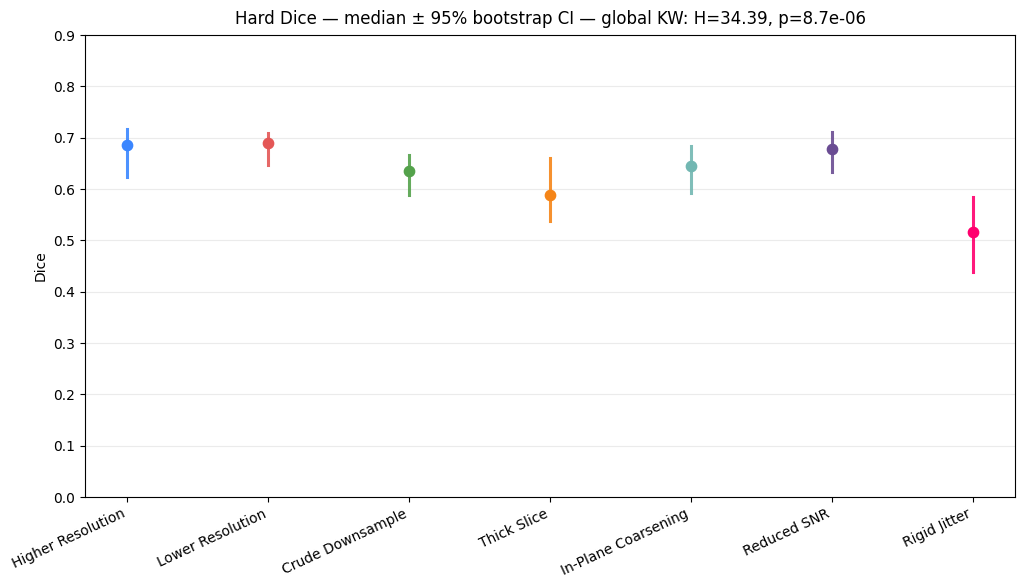

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/kw_summary_hd.png


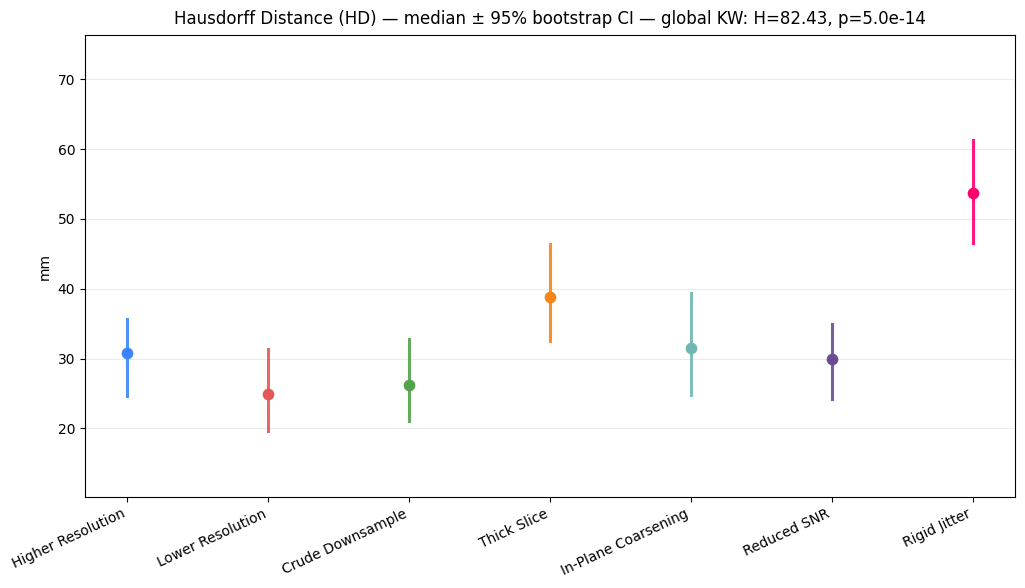

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/kw_summary_assd.png


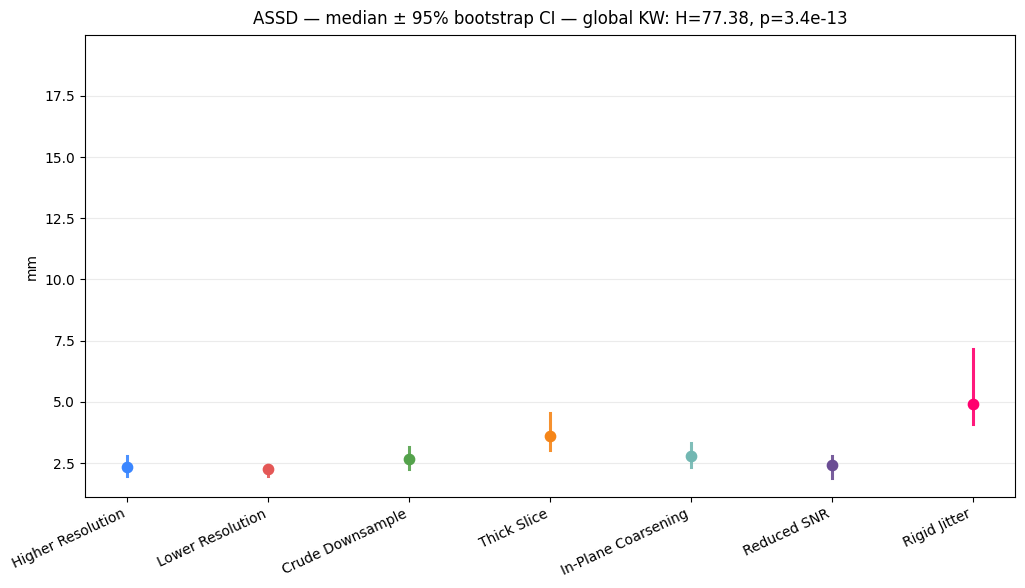

In [ ]:
# === KRUSKAL–WALLIS GLOBAL SUMMARY PLOT ======================================
# For each metric: show per-dataset median with bootstrap 95% CI and KW H,p in the title.
# Depends on: datasets, tag_order, OUT_DIR, PALETTE, ALL_RESULTS, METRICS

import numpy as np
import matplotlib.pyplot as plt

def _vals(datasets, tag, metric):
    return np.array([r[metric] for r in datasets[tag]["rows"] if np.isfinite(r.get(metric, float("nan")))], float)

def bootstrap_ci(a, n_boot=5000, q=(2.5, 97.5), rng=np.random.default_rng(7)):
    a = np.asarray(a, float)
    if a.size == 0:
        return (np.nan, np.nan)
    idx = rng.integers(0, a.size, size=(n_boot, a.size))
    boots = np.median(a[idx], axis=1)
    return (np.percentile(boots, q[0]), np.percentile(boots, q[1]))

def plot_kw_summary(metric_key, title, ylabel, clamp01=False):
    names = tag_order[:]  # preserve your order
    series = [_vals(datasets, t, metric_key) for t in names]
    meds   = [np.median(v) if v.size else np.nan for v in series]
    ci_lo  = []
    ci_hi  = []
    for v in series:
        lo, hi = bootstrap_ci(v) if v.size >= 3 else (np.nan, np.nan)
        ci_lo.append(lo); ci_hi.append(hi)

    # Pull KW H,p from ALL_RESULTS (already computed)
    _, res_unpaired, _ = ALL_RESULTS[metric_key]
    H = res_unpaired["H"] if res_unpaired else np.nan
    p = res_unpaired["p"] if res_unpaired else np.nan

    fig, ax = plt.subplots(figsize=(12, 6))
    xs = np.arange(len(names))
    colors = [PALETTE.get(n, "#999999") for n in names]

    # CIs as vertical lines + markers at medians
    for i,(m,lo,hi) in enumerate(zip(meds, ci_lo, ci_hi)):
        if np.isfinite(m):
            ax.plot([i, i], [lo, hi], lw=2.2, color=colors[i], alpha=0.9)
            ax.scatter(i, m, s=55, color=colors[i], zorder=5)

    ax.set_xticks(xs); ax.set_xticklabels(names, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} — global KW: H={H:.2f}, p={p:.1e}", pad=8)
    ax.grid(True, axis="y", alpha=0.25)

    # y-lims
    flat = np.concatenate([v for v in series if v.size]) if any(v.size for v in series) else np.array([])
    if flat.size:
        lo, hi = np.percentile(flat, [5, 95])
        if clamp01:
            lo, hi = max(0.0, lo), min(1.0, max(0.9, hi))
        if (hi - lo) < 1e-6: hi = lo + 1e-6
        ax.set_ylim(lo, hi)

    out = OUT_DIR / f"kw_summary_{metric_key}.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print("Saved ->", out)
    plt.show()
    return fig

# ---- Make a KW summary figure for each metric
for key, title, units, clamp01 in METRICS:
    ylabel = title if units is None else units
    plot_kw_summary(key, f"{title} — median ± 95% bootstrap CI", ylabel, clamp01=clamp01)


**Cell summary:** Marks the section where the notebook switches to unpaired statistical testing only.


# ###################### EVERYTHING BELOW THIS LINE IS USING UNPAIRED TESTS  ################################

**Cell summary:** Builds pairwise unpaired Mann-Whitney heatmaps and effect-size maps across datasets.

- `Mann-Whitney U` is an **unpaired** rank test for two independent groups.
- Primary heatmap values are Holm-adjusted pairwise `p` values (`P` matrix): smaller values indicate stronger evidence of a between-dataset difference.
- Optional second heatmap shows `Cliff's delta` (`D` matrix), where sign gives direction and absolute value gives effect magnitude.
- Star overlays indicate cells with adjusted `p < alpha`.


Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_p_hard_dice_lower.png


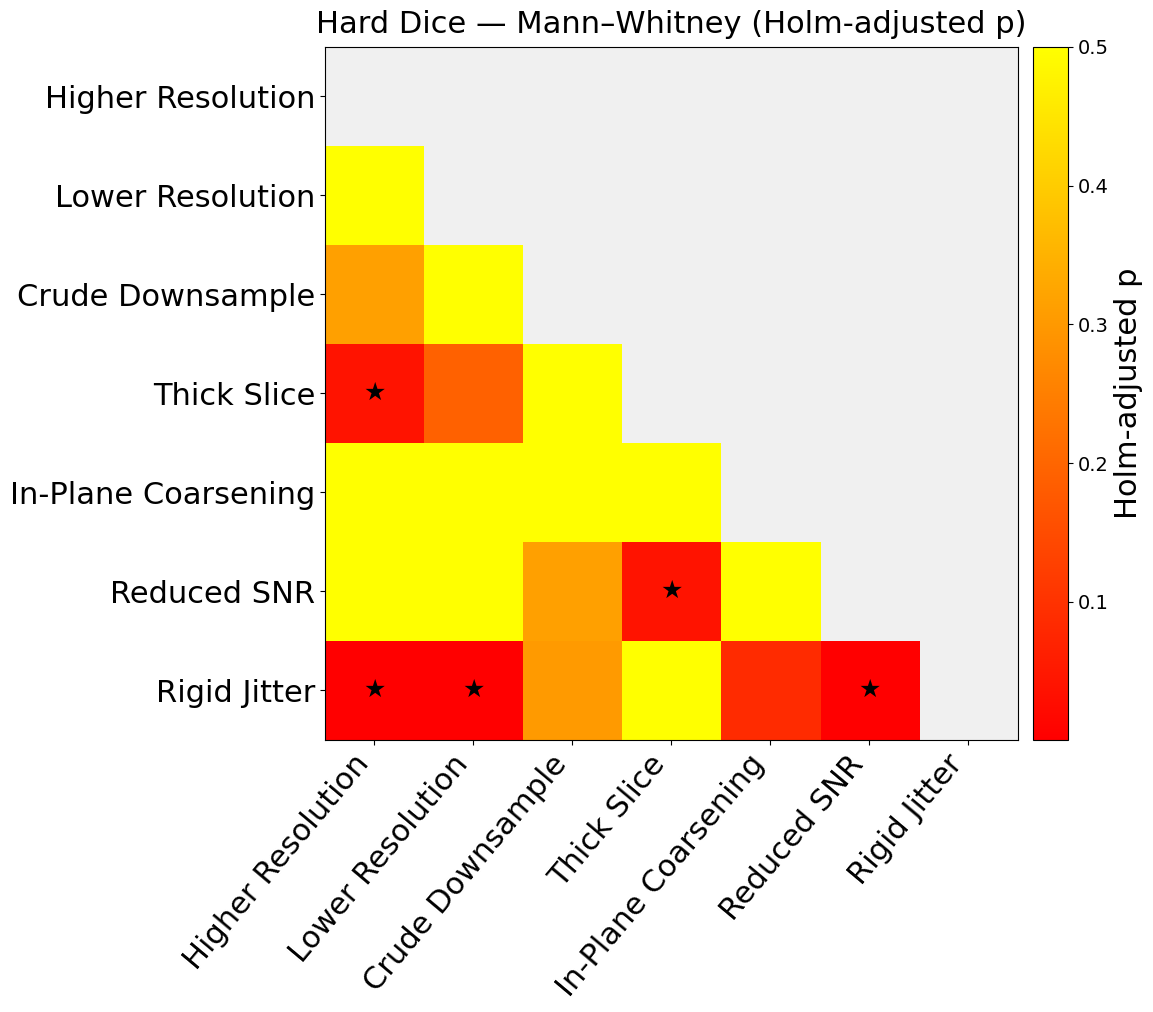

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_delta_hard_dice_lower.png


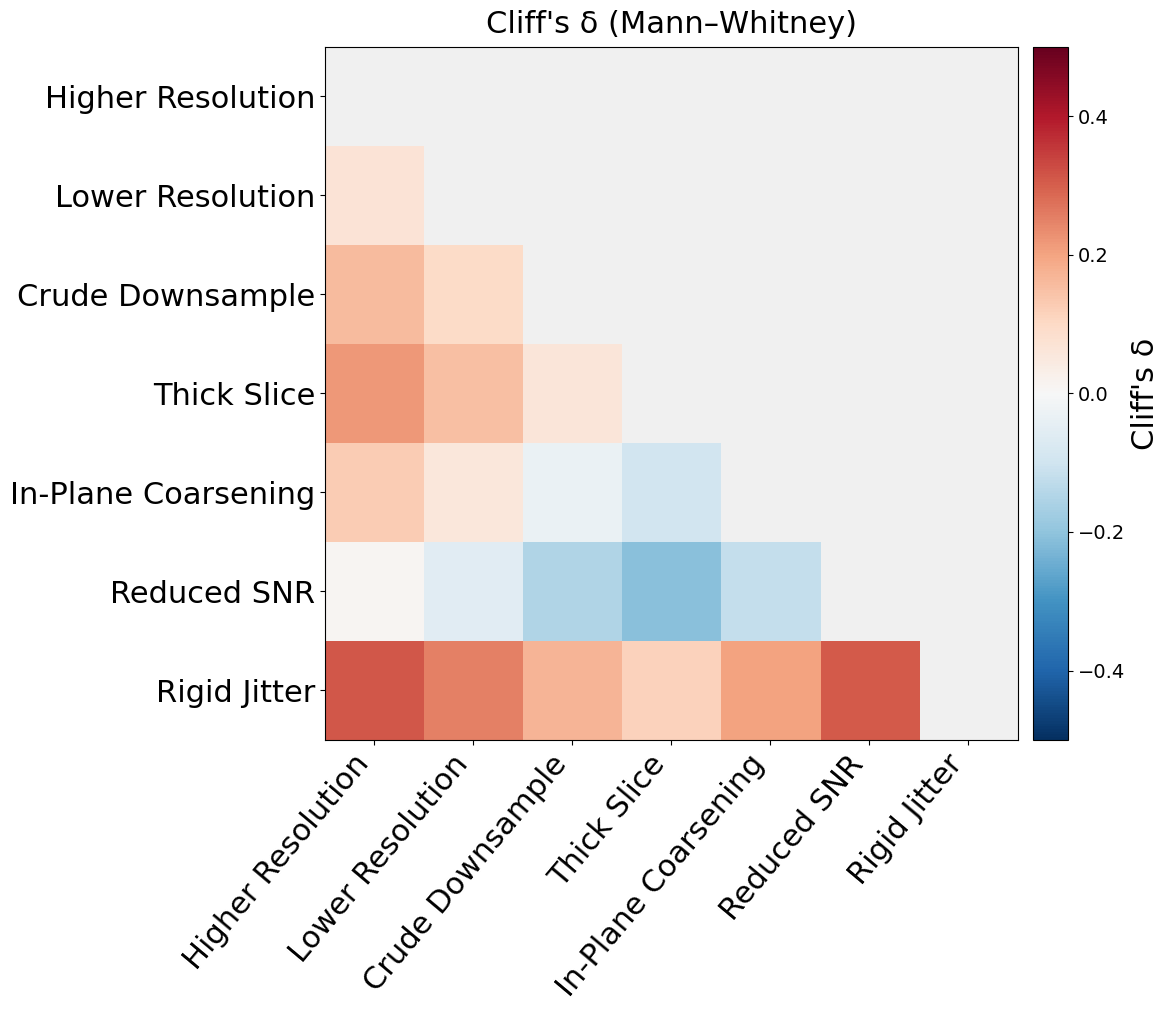

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_p_hd_lower.png


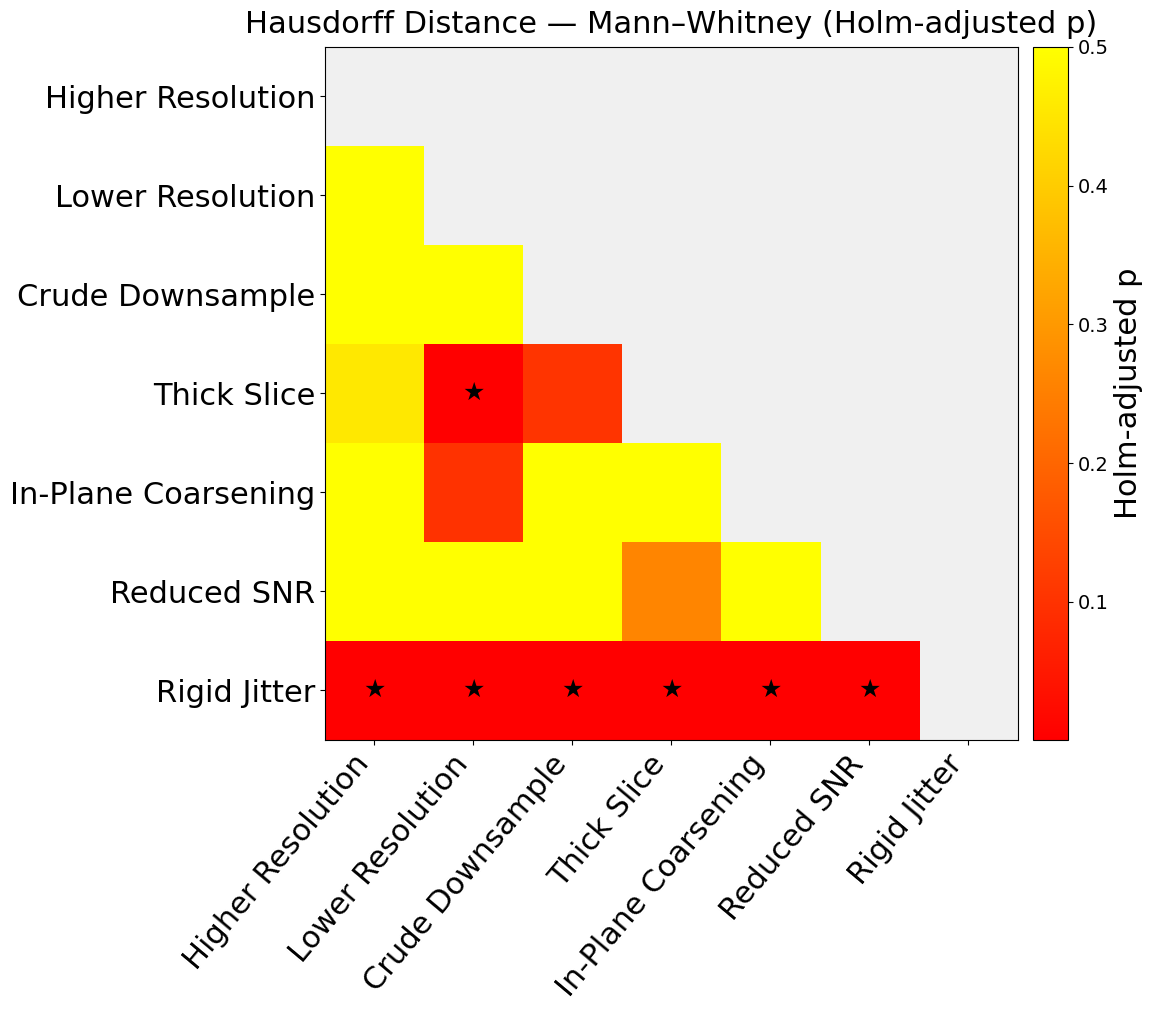

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_delta_hd_lower.png


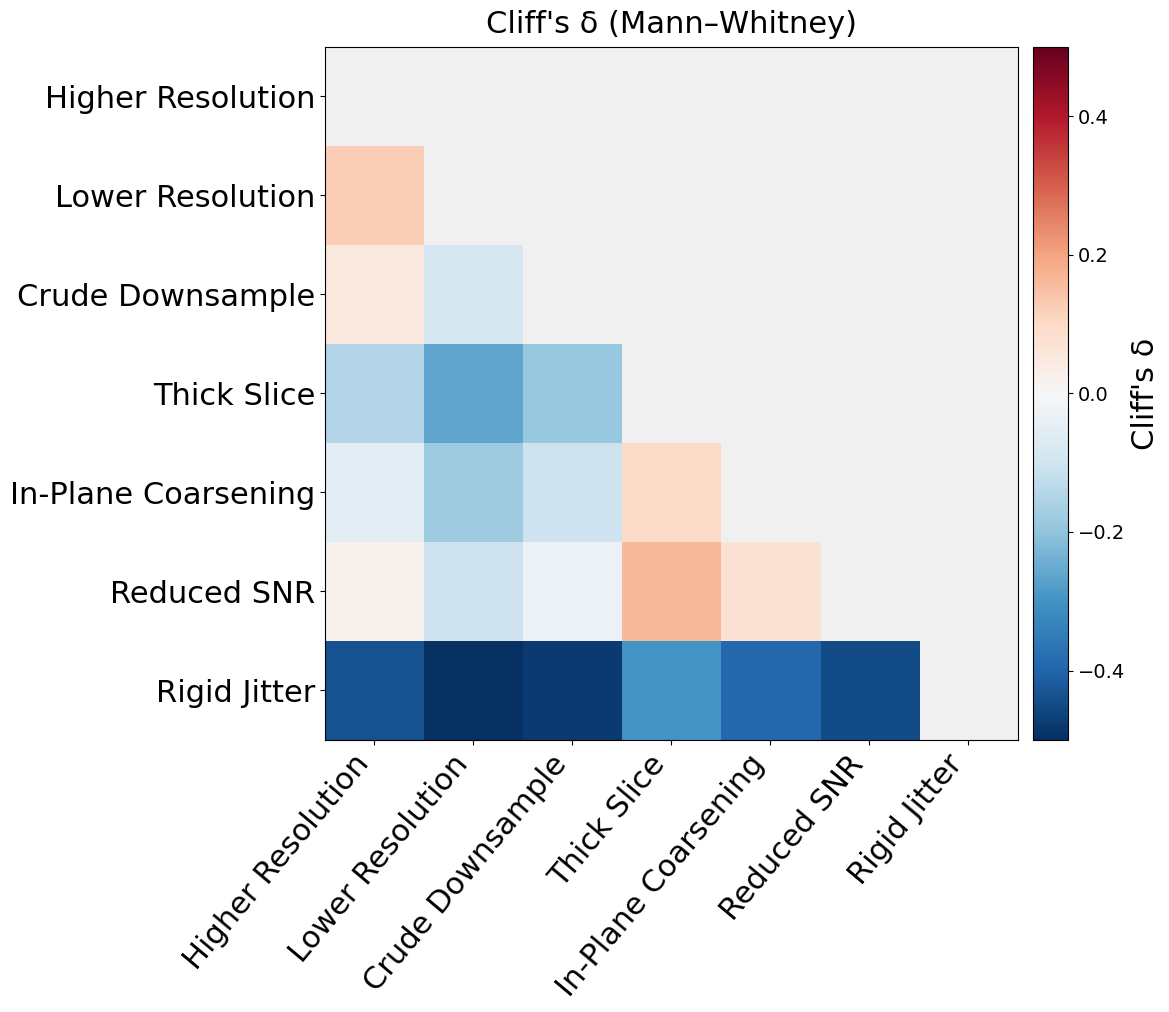

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_p_assd_lower.png


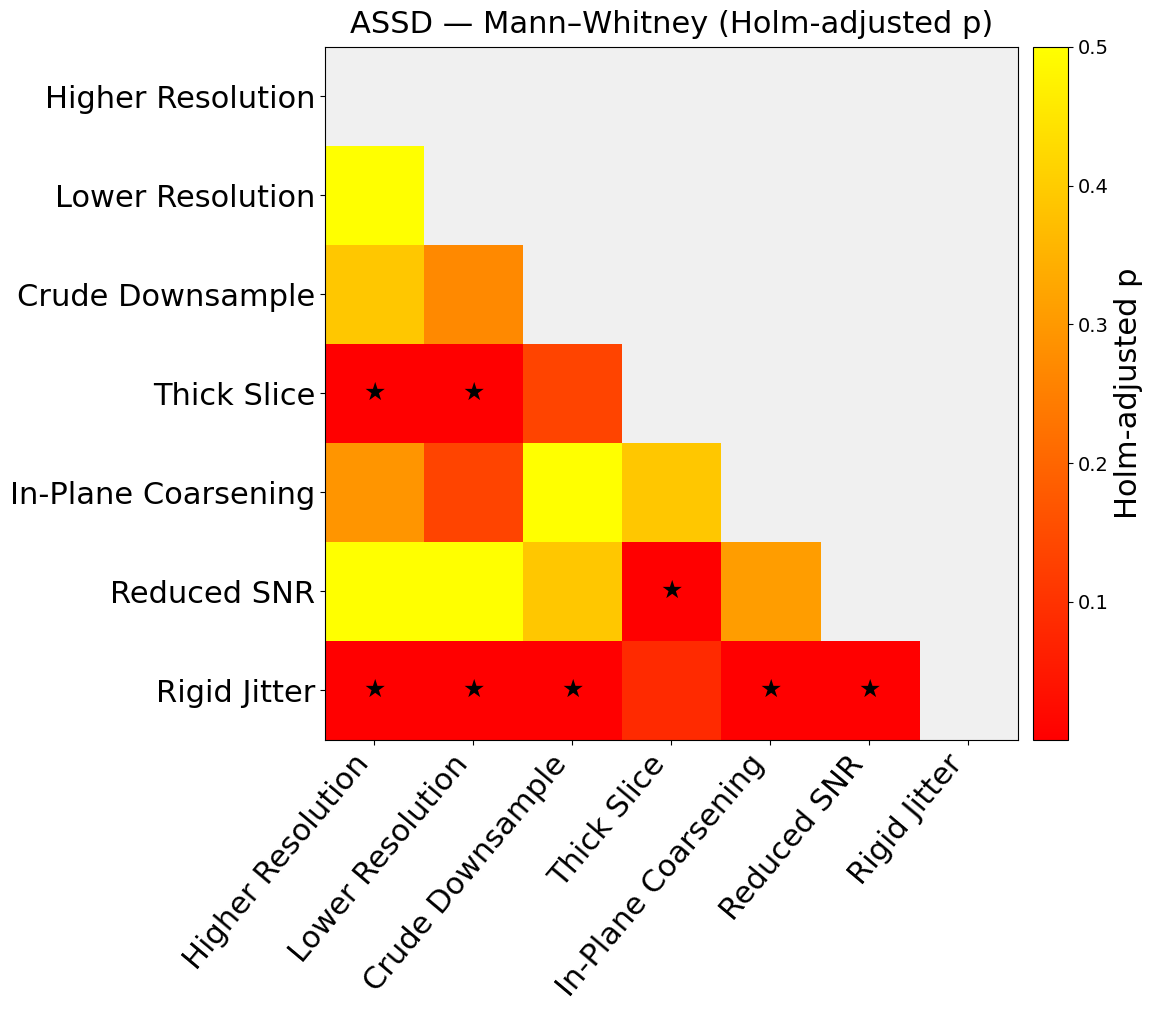

Saved -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/mwu_delta_assd_lower.png


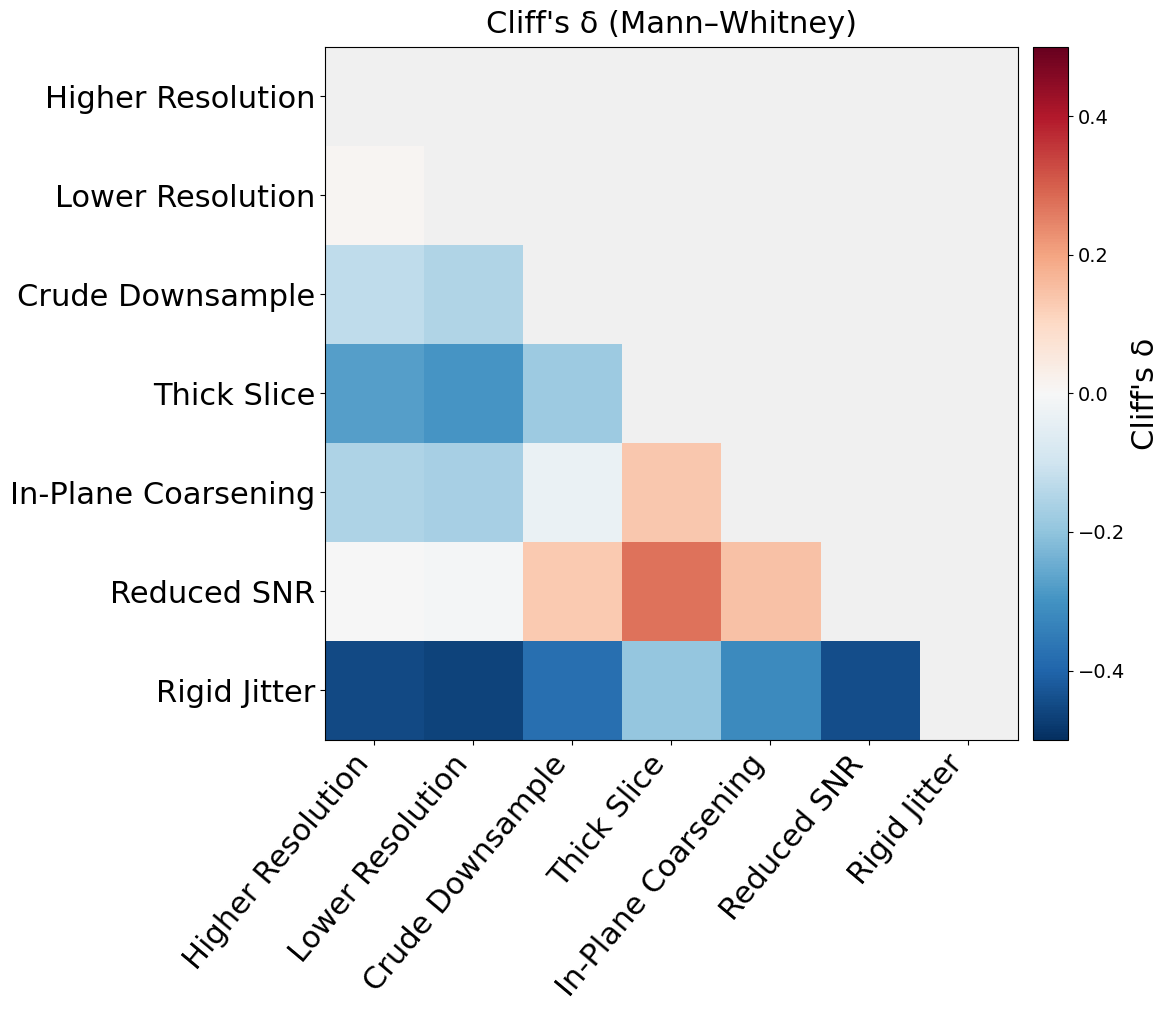

In [ ]:
# ============================
# Mann–Whitney heatmaps (refactored, uniform scale)
# ============================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import colormaps as mcm  # modern cmap getter

# --------- KNOBS & DIALS ----------
CONFIG_MWU = {
    # Which triangle to show: 'lower' or 'upper'
    "triangle": "lower",

    # Significance threshold & star appearance
    "alpha": ALPHA,             # e.g., 0.05
    "star_char": "★",
    "star_size": 18,
    "star_color": "black",
    "star_edgecolor": None,     # e.g., "white"
    "star_edgewidth": 0.0,

    # Figure sizing & text
    "figsize": (10.0, 9.0),
    "x_tick_rotation": 50,
    "x_tick_ha": "right",
    "tick_fontsize": 22,
    "label_fontsize": 22,
    "title_fontsize": 22,

    # ---- P-VALUE HEATMAP SETTINGS (UNIFORM ACROSS METRICS) ----
    "p_cmap": "autumn",         # colormap (light = high p, dark = low p)
    "p_mask_color": "#f0f0f0",
    "p_use_log": False,         # keep linear scale per request
    "p_vmin": 5e-4,             # *** uniform across metrics ***
    "p_vmax": 5e-1,             # *** uniform across metrics ***
    "p_cbar_label": "Holm-adjusted p",
    "p_cbar_ticksize": 14,

    # ---- EFFECT-SIZE (CLIFF'S DELTA) HEATMAP ----
    "show_delta_heatmap": True,
    "delta_cmap": "RdBu_r",
    "delta_mask_color": "#f0f0f0",
    "delta_abs_max": 0.5,       # color limits: [-abs_max, +abs_max]
    "delta_cbar_label": "Cliff's δ",
    "delta_cbar_ticksize": 14,

    # Optional cell annotations
    "annotate_p_values": False,
    "annotate_delta_values": False,
    "annot_fontsize": 12,
    "annot_fmt_p": "{:.3f}",
    "annot_fmt_delta": "{:.2f}",

    # Save options
    "dpi": 180,
}

# Titles per metric (so HD/ASSD aren’t labeled as Dice)
METRIC_MWU_TITLES = {
    "hard_dice": "Hard Dice — Mann–Whitney (Holm-adjusted p)",
    "hd":        "Hausdorff Distance — Mann–Whitney (Holm-adjusted p)",
    "assd":      "ASSD — Mann–Whitney (Holm-adjusted p)",
}

# --------- STATS HELPERS (expects you already defined) ----------
# - mann_whitney(x, y) -> dict with keys 'p', 'cliffs_delta'
# - holm_adjust(pvals) -> np.array of adjusted p-values

def _vals_for(datasets, tag, metric_key):
    return np.array([r[metric_key] for r in datasets[tag]["rows"]
                     if np.isfinite(r.get(metric_key, float("nan")))], float)

def pairwise_mwu_all(datasets, tag_order, metric_key, mann_whitney_fn=None, holm_adjust_fn=None, min_n=3):
    """
    Compute pairwise Mann–Whitney (all datasets), returning:
      P: Holm-adjusted p-value matrix (upper triangle filled at i<j)
      D: Cliff's delta matrix (upper triangle filled at i<j)
    """
    if mann_whitney_fn is None:
        mann_whitney_fn = mann_whitney
    if holm_adjust_fn is None:
        holm_adjust_fn = holm_adjust

    arrs = [_vals_for(datasets, t, metric_key) for t in tag_order]
    n = len(arrs)
    P = np.full((n, n), np.nan, float)
    D = np.full((n, n), np.nan, float)

    pairs, raw_ps, deltas = [], [], []
    for i in range(n):
        for j in range(i+1, n):
            if arrs[i].size >= min_n and arrs[j].size >= min_n:
                mw = mann_whitney_fn(arrs[i], arrs[j])
                pairs.append((i, j))
                raw_ps.append(mw["p"])
                deltas.append(mw["cliffs_delta"])
            else:
                pairs.append((i, j))
                raw_ps.append(np.nan)
                deltas.append(np.nan)

    raw_ps = np.array(raw_ps, float)
    valid = np.isfinite(raw_ps)
    adj = np.full_like(raw_ps, np.nan, dtype=float)
    if np.any(valid):
        adj_valid = holm_adjust_fn(raw_ps[valid])
        adj[valid] = adj_valid

    for (i, j), p_adj, delta in zip(pairs, adj, deltas):
        P[i, j] = p_adj
        D[i, j] = delta

    return P, D

# --------- DISPLAY HELPERS ----------
def mirror_to_triangle(M, which="lower"):
    """
    M has values in the UPPER triangle (i<j). Return a matrix with values
    copied into the requested triangle and NaNs elsewhere.
    """
    M = np.asarray(M, float)
    n = M.shape[0]
    out = np.full_like(M, np.nan)
    iu = np.triu_indices(n, 1)   # upper off-diagonal
    if which == "lower":
        out[iu[1], iu[0]] = M[iu]  # move to lower
    else:  # "upper"
        out[iu] = M[iu]
    return out

def _get_cmap(name, bad="#f0f0f0"):
    cmap = mcm[name]
    try:
        cmap = cmap.with_extremes(bad=bad)  # Matplotlib ≥ 3.6
    except Exception:
        cmap = cmap.copy(); cmap.set_bad(bad)
    return cmap

def plot_mwu_heatmaps(metric_key, tag_order, datasets, cfg=CONFIG_MWU, out_dir=OUT_DIR):
    names = tag_order[:]
    P_full, D_full = pairwise_mwu_all(datasets, names, metric_key)

    tri = cfg.get("triangle", "lower")
    P = mirror_to_triangle(P_full, tri)
    D = mirror_to_triangle(D_full, tri)

    # ---------- P-VALUE HEATMAP ----------
    fig, ax = plt.subplots(figsize=cfg["figsize"])
    cmap = _get_cmap(cfg["p_cmap"], bad=cfg["p_mask_color"])
    M = np.ma.array(P, mask=~np.isfinite(P))

    if cfg.get("p_use_log", False):
        norm = LogNorm(vmin=cfg["p_vmin"], vmax=cfg["p_vmax"])
        im = ax.imshow(M, cmap=cmap, norm=norm)
    else:
        im = ax.imshow(M, cmap=cmap, vmin=cfg["p_vmin"], vmax=cfg["p_vmax"])

    ax.set_xticks(np.arange(len(names))); ax.set_yticks(np.arange(len(names)))
    ax.set_xticklabels(names, rotation=cfg["x_tick_rotation"], ha=cfg["x_tick_ha"], fontsize=cfg["tick_fontsize"])
    ax.set_yticklabels(names, fontsize=cfg["tick_fontsize"])

    # Metric-specific title (no hard-coded "Dice")
    ax.set_title(METRIC_MWU_TITLES.get(metric_key, "Mann–Whitney (Holm-adjusted p)"),
                 fontsize=cfg["title_fontsize"], pad=10)

    # Stars + optional p annotations
    for i in range(len(names)):
        for j in range(len(names)):
            if not np.isfinite(P[i, j]): 
                continue
            p = P[i, j]
            if p < cfg["alpha"]:
                ax.text(j, i, cfg["star_char"], ha="center", va="center",
                        fontsize=cfg["star_size"], color=cfg["star_color"],
                        path_effects=None)
            if cfg["annotate_p_values"]:
                ax.text(j, i, cfg["annot_fmt_p"].format(p), ha="center", va="center",
                        fontsize=cfg["annot_fontsize"], color="black")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(cfg["p_cbar_label"], fontsize=cfg["label_fontsize"])
    cbar.ax.tick_params(labelsize=cfg["p_cbar_ticksize"])

    out_p = out_dir / f"mwu_p_{metric_key}_{tri}.png"
    fig.savefig(out_p, dpi=cfg["dpi"], bbox_inches="tight")
    print("Saved ->", out_p)
    plt.show()

    # ---------- DELTA HEATMAP (optional) ----------
    if cfg.get("show_delta_heatmap", True):
        fig2, ax2 = plt.subplots(figsize=cfg["figsize"])
        cmap2 = _get_cmap(cfg["delta_cmap"], bad=cfg["delta_mask_color"])
        vmax = cfg["delta_abs_max"]
        M2 = np.ma.array(D, mask=~np.isfinite(D))
        im2 = ax2.imshow(M2, cmap=cmap2, vmin=-vmax, vmax=vmax)
        ax2.set_xticks(np.arange(len(names))); ax2.set_yticks(np.arange(len(names)))
        ax2.set_xticklabels(names, rotation=cfg["x_tick_rotation"], ha=cfg["x_tick_ha"], fontsize=cfg["tick_fontsize"])
        ax2.set_yticklabels(names, fontsize=cfg["tick_fontsize"])
        ax2.set_title("Cliff's δ (Mann–Whitney)", fontsize=cfg["title_fontsize"], pad=10)

        if cfg["annotate_delta_values"]:
            for i in range(len(names)):
                for j in range(len(names)):
                    if not np.isfinite(D[i, j]): 
                        continue
                    ax2.text(j, i, cfg["annot_fmt_delta"].format(D[i, j]),
                             ha="center", va="center", fontsize=cfg["annot_fontsize"], color="black")

        cbar2 = fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)
        cbar2.set_label(cfg["delta_cbar_label"], fontsize=cfg["label_fontsize"])
        cbar2.ax.tick_params(labelsize=cfg["delta_cbar_ticksize"])

        out_d = out_dir / f"mwu_delta_{metric_key}_{tri}.png"
        fig2.savefig(out_d, dpi=cfg["dpi"], bbox_inches="tight")
        print("Saved ->", out_d)
        plt.show()

# ---------- Run for all metrics (uniform p-scale across all three) ----------
for key, title, units, clamp01 in METRICS:
    plot_mwu_heatmaps(metric_key=key, tag_order=tag_order, datasets=datasets, cfg=CONFIG_MWU, out_dir=OUT_DIR)
